# Retardo efectivo del filtrado de CO₂ — Laboratorio 2026

Este notebook inventaría programáticamente los CSV de CO₂ en `data/Laboratorio 2026/raw_data`, deduplica copias exactas mediante SHA-256, forma pares RAW/FILT por experimento y segmento, y estima el **retardo efectivo de la cadena causal RAW → Hampel → Butterworth → FILT**.

Convención usada en todo el análisis:

> **delay > 0 significa que FILT aparece retrasado respecto de RAW.**

No se modifica ningún CSV original. Todos los resultados derivados se escriben en `laboratory_2026/results/co2_filter_delay_analysis/`.

Criterios principales:

- Los archivos con `FILT` o `co2f` se clasifican como FILT; los restantes, como RAW.
- `labNNN` determina el experimento y la secuencia cíclica determina F1/F2/F3 cuando el fermentador no está escrito en el nombre.
- Los sufijos `pt2`, `pt3` y fechas forman segmentos distintos del mismo experimento.
- Se selecciona un segmento representativo por experimento, priorizando amplitud dinámica, duración, superposición, timestamps válidos y correlación coherente.
- Para mitigar spikes sin introducir fase se usa una mediana **centrada** de 120 s sobre RAW sólo para el análisis. La correlación de niveles usa suavizado Savitzky–Golay centrado de 15 min y la de derivadas, de 60 min.
- Las correlaciones se limitan a ±3 h y se validó el signo con una señal sintética.


In [1]:
import sys
print(sys.executable)

import numpy as np
import pandas as pd
import scipy
import matplotlib

print("Kernel OK")

D:\anaconda3\envs\fermentation\python.exe


Kernel OK


In [2]:
from pathlib import Path
import hashlib
import math
import re
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy import signal

warnings.filterwarnings("ignore", category=RuntimeWarning)
plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 180)

cwd = Path.cwd().resolve()
FM_ROOT = None
for candidate in (cwd, *cwd.parents):
    if candidate.name == "fermentation_model":
        FM_ROOT = candidate
        break
    if (candidate / "fermentation_model").is_dir():
        FM_ROOT = candidate / "fermentation_model"
        break
if FM_ROOT is None:
    raise FileNotFoundError("No se pudo localizar fermentation_model desde el directorio de trabajo.")

RAW_ROOT = FM_ROOT / "data" / "Laboratorio 2026" / "raw_data"
RESULTS = FM_ROOT / "laboratory_2026" / "results" / "co2_filter_delay_analysis"
FIGURES = RESULTS / "figures"
FILTER_SOURCE = (
    FM_ROOT / "legacy" / "rendicion" / "technical_reports"
    / "A03_ensayos_estaciones_fermentacion_laboratorio"
    / "NEW_GUI_filtrado_vCTORREALBA.py"
)
NOTEBOOK_PATH = FM_ROOT / "laboratory_2026" / "notebooks" / "diagnostics" / "co2_filter_delay_analysis_lab2026.ipynb"

assert RAW_ROOT.is_dir(), RAW_ROOT
assert FILTER_SOURCE.is_file(), FILTER_SOURCE
RESULTS.mkdir(parents=True, exist_ok=True)
FIGURES.mkdir(parents=True, exist_ok=True)

print("fermentation_model:", FM_ROOT)
print("Datos RAW:", RAW_ROOT)
print("Resultados:", RESULTS)


fermentation_model: D:\claud\Desktop\Universidad\Memoria\Model\pyomo-doe\fermentation_model
Datos RAW: D:\claud\Desktop\Universidad\Memoria\Model\pyomo-doe\fermentation_model\data\Laboratorio 2026\raw_data
Resultados: D:\claud\Desktop\Universidad\Memoria\Model\pyomo-doe\fermentation_model\laboratory_2026\results\co2_filter_delay_analysis


## 1. Inventario programático y deduplicación

Se leen sólo las columnas y estadísticas necesarias. El inventario conserva todos los archivos físicos, pero el emparejamiento utiliza una única copia canónica por SHA-256.


In [3]:
def classify_file(path: Path) -> dict:
    low = path.name.lower()
    role = "FILT" if ("filt" in low or re.search(r"co2f(?:_|\.)", low)) else "RAW"
    lab_match = re.search(r"lab0*(\d+)", low)
    lab_number = int(lab_match.group(1)) if lab_match else None
    lab_id = f"lab{lab_number:03d}" if lab_number is not None else None

    ferm_match = re.search(r"(?:^|_)f([123])(?:_|\.|$)", low)
    fermenter_from_name = f"F{ferm_match.group(1)}" if ferm_match else None
    fermenter_expected = f"F{((lab_number - 1) % 3) + 1}" if lab_number is not None else None
    fermenter = fermenter_from_name or fermenter_expected

    part_match = re.search(r"pt\.?\s*(\d+)", low)
    date_match = re.search(r"(\d{2}_\d{2}_\d{2}_\d{4})", low)
    if part_match:
        segment = f"pt{int(part_match.group(1))}"
    elif date_match:
        segment = date_match.group(1)
    else:
        segment = "main"

    return {
        "role": role,
        "lab_id": lab_id,
        "lab_number": lab_number,
        "fermenter": fermenter,
        "fermenter_from_name": fermenter_from_name,
        "fermenter_expected": fermenter_expected,
        "fermenter_matches_cycle": (
            fermenter_from_name in (None, fermenter_expected)
            if lab_number is not None else True
        ),
        "segment": segment,
    }


def inspect_csv(path: Path) -> dict:
    info = classify_file(path)
    frame = pd.read_csv(path)
    timestamp_column = next((c for c in frame.columns if "time" in c.lower()), None)
    expected_value = "flow_filt_sccm" if info["role"] == "FILT" else "flow_sccm"
    value_column = expected_value if expected_value in frame.columns else None

    timestamps = (
        pd.to_datetime(frame[timestamp_column], errors="coerce")
        if timestamp_column else pd.Series(pd.NaT, index=frame.index)
    )
    valid = timestamps.dropna().sort_values()
    differences = valid.diff().dt.total_seconds().dropna()
    positive_dt = differences[differences > 0]
    sample_s = float(positive_dt.median()) if len(positive_dt) else np.nan
    meaningful_gap_s = max(60.0, 5.0 * sample_s) if np.isfinite(sample_s) else np.inf

    duration_s = (
        float((valid.max() - valid.min()).total_seconds()) if len(valid) else np.nan
    )
    return {
        **info,
        "relative_path": str(path.relative_to(RAW_ROOT)),
        "file": path.name,
        "size_bytes": path.stat().st_size,
        "sha256": hashlib.sha256(path.read_bytes()).hexdigest(),
        "columns": "|".join(frame.columns),
        "timestamp_column": timestamp_column,
        "value_column": value_column,
        "rows": len(frame),
        "start": valid.min() if len(valid) else pd.NaT,
        "end": valid.max() if len(valid) else pd.NaT,
        "duration_h": duration_s / 3600.0 if np.isfinite(duration_s) else np.nan,
        "sample_s_p05": float(positive_dt.quantile(0.05)) if len(positive_dt) else np.nan,
        "sample_s_median": sample_s,
        "sample_s_p95": float(positive_dt.quantile(0.95)) if len(positive_dt) else np.nan,
        "invalid_timestamps": int(timestamps.isna().sum()),
        "duplicate_timestamps": int(timestamps.duplicated().sum()),
        "meaningful_gaps": int((differences > meaningful_gap_s).sum()),
        "nan_values_total": int(frame.isna().sum().sum()),
    }


co2_files = sorted(
    (p for p in RAW_ROOT.rglob("*.csv") if "co2" in p.name.lower()),
    key=lambda p: str(p).lower(),
)
inventory = pd.DataFrame(inspect_csv(path) for path in co2_files)
inventory["path_depth"] = inventory["relative_path"].map(lambda x: len(Path(x).parts))
inventory = inventory.sort_values(["sha256", "path_depth", "relative_path"]).reset_index(drop=True)
inventory["canonical_file"] = ~inventory.duplicated("sha256", keep="first")
canonical_path = inventory.loc[inventory["canonical_file"], ["sha256", "relative_path"]].rename(
    columns={"relative_path": "canonical_relative_path"}
)
inventory = inventory.merge(canonical_path, on="sha256", how="left")
inventory["duplicate_copy"] = ~inventory["canonical_file"]
inventory = inventory.sort_values(["lab_number", "segment", "role", "relative_path"], na_position="last")

inventory.to_csv(RESULTS / "file_inventory.csv", index=False)

counts = inventory.groupby("role").size().rename("physical_files")
unique_counts = inventory[inventory["canonical_file"]].groupby("role").size().rename("unique_files")
inventory_counts = pd.concat([counts, unique_counts], axis=1).fillna(0).astype(int)
display(inventory_counts)
print(f"Archivos físicos: {len(inventory)}")
print(f"Contenidos únicos: {inventory['sha256'].nunique()}")
print(f"Copias físicas duplicadas: {inventory['duplicate_copy'].sum()}")
display(
    inventory[
        [
            "lab_id", "fermenter", "role", "segment", "relative_path", "rows",
            "start", "end", "duration_h", "sample_s_median",
            "invalid_timestamps", "duplicate_timestamps", "meaningful_gaps",
            "duplicate_copy",
        ]
    ].reset_index(drop=True)
)


,physical_files,unique_files
role,,
FILT,31,24
RAW,34,27


Archivos físicos: 65
Contenidos únicos: 51
Copias físicas duplicadas: 14


,lab_id,fermenter,role,segment,relative_path,rows,start,end,duration_h,sample_s_median,invalid_timestamps,duplicate_timestamps,meaningful_gaps,duplicate_copy
0,lab001,F1,FILT,28_03_26_1700,CO2_FILT_lab001_28_03_26_1700.csv,9121,2026-03-28 17:25:33,2026-03-29 19:34:43,26.152778,10.0,0,0,0,False
1,lab001,F1,FILT,28_03_26_1700,Desktop_CyT_Tablero_Proceso\CO2_FILT_lab001_28...,9121,2026-03-28 17:25:33,2026-03-29 19:34:43,26.152778,10.0,0,0,0,True
2,lab001,F1,RAW,28_03_26_1700,CO2_lab001_28_03_26_1700.csv,9124,2026-03-28 17:25:02,2026-03-29 19:34:43,26.161389,10.0,0,0,0,False
3,lab001,F1,RAW,28_03_26_1700,Desktop_CyT_Tablero_Proceso\CO2_lab001_28_03_2...,9124,2026-03-28 17:25:02,2026-03-29 19:34:43,26.161389,10.0,0,0,0,True
4,lab001,F1,FILT,pt2,Desktop_CyT_Tablero_Proceso\lab001_co2f_pt2.csv,5641,2026-03-29 19:58:59,2026-03-30 12:04:11,16.086667,10.0,0,0,0,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60,lab012,F3,FILT,pt2,CO2_FILT_F3_lab12_PT2.csv,56763,2026-05-13 14:40:31,2026-05-22 09:25:51,210.755556,15.0,0,0,1,False
61,lab012,F3,RAW,pt2,CO2_F3_lab12_PT2.csv,56760,2026-05-13 14:40:31,2026-05-22 09:25:20,210.746944,15.0,0,0,1,False
62,None,F1,RAW,main,Desktop_CyT_Tablero_Proceso\CO2_F1.csv,47993,2026-02-19 17:42:55,2026-02-25 12:01:33,138.310556,10.0,0,0,0,False
63,None,F2,RAW,main,Desktop_CyT_Tablero_Proceso\CO2_F2.csv,47993,2026-02-19 17:42:55,2026-02-25 12:01:33,138.310556,10.0,0,0,0,False


In [4]:
canonical = inventory[inventory["canonical_file"]].copy()
pair_rows = []
for (lab_id, fermenter, segment), group in canonical[canonical["lab_id"].notna()].groupby(
    ["lab_id", "fermenter", "segment"], dropna=False
):
    raw = group[group["role"] == "RAW"]
    filt = group[group["role"] == "FILT"]
    raw_row = raw.iloc[0] if len(raw) else None
    filt_row = filt.iloc[0] if len(filt) else None
    complete = raw_row is not None and filt_row is not None

    overlap_start = max(raw_row["start"], filt_row["start"]) if complete else pd.NaT
    overlap_end = min(raw_row["end"], filt_row["end"]) if complete else pd.NaT
    overlap_h = (
        max(0.0, (overlap_end - overlap_start).total_seconds() / 3600.0)
        if complete else 0.0
    )
    raw_dt = raw_row["sample_s_median"] if raw_row is not None else np.nan
    filt_dt = filt_row["sample_s_median"] if filt_row is not None else np.nan
    sample_compatible = (
        bool(abs(raw_dt - filt_dt) <= max(2.0, 0.2 * max(raw_dt, filt_dt)))
        if complete and np.isfinite(raw_dt) and np.isfinite(filt_dt) else False
    )

    pair_rows.append(
        {
            "lab_id": lab_id,
            "lab_number": int(lab_id[-3:]),
            "fermenter": fermenter,
            "segment": segment,
            "complete": complete,
            "raw_file": raw_row["relative_path"] if raw_row is not None else None,
            "filt_file": filt_row["relative_path"] if filt_row is not None else None,
            "raw_rows": raw_row["rows"] if raw_row is not None else np.nan,
            "filt_rows": filt_row["rows"] if filt_row is not None else np.nan,
            "raw_start": raw_row["start"] if raw_row is not None else pd.NaT,
            "raw_end": raw_row["end"] if raw_row is not None else pd.NaT,
            "filt_start": filt_row["start"] if filt_row is not None else pd.NaT,
            "filt_end": filt_row["end"] if filt_row is not None else pd.NaT,
            "overlap_h": overlap_h,
            "raw_sample_s": raw_dt,
            "filt_sample_s": filt_dt,
            "sample_compatible": sample_compatible,
            "invalid_timestamps": (
                int(raw_row["invalid_timestamps"] + filt_row["invalid_timestamps"])
                if complete else np.nan
            ),
            "meaningful_gaps": (
                int(raw_row["meaningful_gaps"] + filt_row["meaningful_gaps"])
                if complete else np.nan
            ),
        }
    )

pairs = pd.DataFrame(pair_rows).sort_values(["lab_number", "segment"]).reset_index(drop=True)
print(f"Claves de segmento: {len(pairs)}")
print(f"Pares RAW/FILT completos: {pairs['complete'].sum()}")
display(pairs)


Claves de segmento: 24
Pares RAW/FILT completos: 24


,lab_id,lab_number,fermenter,segment,complete,raw_file,filt_file,raw_rows,filt_rows,raw_start,raw_end,filt_start,filt_end,overlap_h,raw_sample_s,filt_sample_s,sample_compatible,invalid_timestamps,meaningful_gaps
0,lab001,1,F1,28_03_26_1700,True,CO2_lab001_28_03_26_1700.csv,CO2_FILT_lab001_28_03_26_1700.csv,9124,9121,2026-03-28 17:25:02,2026-03-29 19:34:43,2026-03-28 17:25:33,2026-03-29 19:34:43,26.152778,10.0,10.0,True,0,0
1,lab001,1,F1,pt2,True,lab001_co2_pt2.csv,lab001_co2f_pt2.csv,5642,5641,2026-03-29 19:58:49,2026-03-30 12:04:11,2026-03-29 19:58:59,2026-03-30 12:04:11,16.086667,10.0,10.0,True,0,0
2,lab001,1,F1,pt3,True,Desktop_CyT_Tablero_Proceso\CO2_F1_lab001_pt3.csv,Desktop_CyT_Tablero_Proceso\CO2_FILT_F1_lab001...,15783,15783,2026-03-30 12:18:47,2026-04-01 09:16:48,2026-03-30 12:18:47,2026-04-01 09:16:48,44.966944,10.0,10.0,True,0,0
3,lab002,2,F2,29_03_26_1700,True,CO2_lab002_29_03_26_1700.csv,CO2_FILT_lab002_29_03_26_1700.csv,403,403,2026-03-29 18:25:22,2026-03-29 19:34:43,2026-03-29 18:25:22,2026-03-29 19:34:43,1.155833,10.0,10.0,True,0,0
4,lab002,2,F2,pt2,True,lab002_co2_pt2.csv,lab002_co2f_pt2.csv,5638,5634,2026-03-29 19:59:29,2026-03-30 12:04:11,2026-03-29 20:00:10,2026-03-30 12:04:11,16.066944,10.0,10.0,True,0,0
5,lab002,2,F2,pt3,True,CO2_F2_lab002_pt3.csv,CO2_FILT_F2_lab002_pt3.csv,15781,15780,2026-03-30 12:19:07,2026-04-01 09:16:48,2026-03-30 12:19:18,2026-04-01 09:16:48,44.958333,10.0,10.0,True,0,0
6,lab003,3,F3,29_03_26_1700,True,CO2_lab003_29_03_26_1700.csv,CO2_FILT_lab003_29_03_26_1700.csv,405,404,2026-03-29 18:25:11,2026-03-29 19:34:54,2026-03-29 18:25:22,2026-03-29 19:34:54,1.158889,10.0,10.0,True,0,0
7,lab003,3,F3,pt2,True,lab003_co2_pt2.csv,lab003_co2f_pt2.csv,5637,5634,2026-03-29 19:59:40,2026-03-30 12:04:11,2026-03-29 20:00:10,2026-03-30 12:04:11,16.066944,10.0,10.0,True,0,0
8,lab003,3,F3,pt3,True,Desktop_CyT_Tablero_Proceso\CO2_F3_lab003_pt3.csv,Desktop_CyT_Tablero_Proceso\CO2_FILT_F3_lab003...,15779,15778,2026-03-30 12:19:38,2026-04-01 09:16:58,2026-03-30 12:19:48,2026-04-01 09:16:58,44.952778,10.0,10.0,True,0,0
9,lab004,4,F1,main,True,Desktop_CyT_Tablero_Proceso\CO2_F1_lab004.csv,Desktop_CyT_Tablero_Proceso\CO2_FILT_F1_lab004...,5780,5779,2026-04-06 14:46:32,2026-04-07 07:13:18,2026-04-06 14:46:42,2026-04-07 07:13:18,16.443333,10.0,10.0,True,0,0


## 2. Evidencia del filtro y retardo teórico

El código histórico encontrado usa exactamente las columnas de los archivos FILT (`flow_filt_sccm`, `is_spike`) y una cadena causal Hampel + Butterworth SOS. Los parámetros se extraen automáticamente del archivo fuente para evitar transcribirlos manualmente.

El período observado en los CSV puede diferir ligeramente del período nominal por la planificación de adquisición. Para la comparación teórica se calculan curvas para todos los períodos medianos observados.


In [5]:
filter_text = FILTER_SOURCE.read_text(encoding="utf-8", errors="replace")

def extract_numeric_assignment(name: str) -> float:
    match = re.search(rf"^\s*{re.escape(name)}\s*=\s*([0-9.]+)", filter_text, flags=re.MULTILINE)
    if not match:
        raise ValueError(f"No se encontró {name} en {FILTER_SOURCE}")
    return float(match.group(1))

W_SPIKE_SECONDS = extract_numeric_assignment("W_SPIKE_SECONDS")
HAMPEL_K = extract_numeric_assignment("K")
MIN_ABS_SPIKE = extract_numeric_assignment("MIN_ABS_SPIKE")
TAU_SECONDS = extract_numeric_assignment("TAU_SECONDS")
BUTTER_ORDER = int(extract_numeric_assignment("BUTTER_ORDER"))
CUTOFF_HZ = 1.0 / (2.0 * np.pi * TAU_SECONDS)

filter_parameters = pd.DataFrame(
    [
        ("hampel_window_seconds", W_SPIKE_SECONDS, "s", "Código histórico"),
        ("hampel_k", HAMPEL_K, "-", "Código histórico"),
        ("hampel_min_abs_spike", MIN_ABS_SPIKE, "sccm", "Código histórico"),
        ("butterworth_order", BUTTER_ORDER, "-", "Código histórico"),
        ("butterworth_tau", TAU_SECONDS, "s", "Código histórico"),
        ("butterworth_cutoff", CUTOFF_HZ, "Hz", "fc = 1/(2*pi*tau)"),
        ("butterworth_cutoff_period", 1.0 / CUTOFF_HZ / 60.0, "min", "1/fc"),
    ],
    columns=["parameter", "value", "unit", "evidence"],
)
filter_parameters.to_csv(RESULTS / "filter_parameters.csv", index=False)
display(filter_parameters)

observed_periods = sorted(
    inventory.loc[inventory["canonical_file"], "sample_s_median"].dropna().unique()
)
print("Períodos medianos observados [s]:", observed_periods)
print(
    "Ventana Hampel equivalente [muestras]:",
    {dt: int(round(W_SPIKE_SECONDS / dt)) for dt in observed_periods},
)


,parameter,value,unit,evidence
0,hampel_window_seconds,120.000000,s,Código histórico
1,hampel_k,3.500000,-,Código histórico
2,hampel_min_abs_spike,0.500000,sccm,Código histórico
3,butterworth_order,3.000000,-,Código histórico
4,butterworth_tau,1200.000000,s,Código histórico
5,butterworth_cutoff,0.000133,Hz,fc = 1/(2*pi*tau)
6,butterworth_cutoff_period,125.663706,min,1/fc


Períodos medianos observados [s]: [10.0, 11.0, 15.0]
Ventana Hampel equivalente [muestras]: {10.0: 12, 11.0: 11, 15.0: 8}


,sample_s,feature_period_h,frequency_hz,group_delay_samples,group_delay_s,group_delay_min
0,10.0,inf,0.0000,239.9986,2399.9861,39.9998
1,10.0,0.5,0.0006,14.1114,141.1139,2.3519
2,10.0,1.0,0.0003,63.0482,630.4817,10.5080
3,10.0,2.0,0.0001,284.7286,2847.2865,47.4548
4,10.0,4.0,0.0001,285.0627,2850.6270,47.5104
5,10.0,8.0,0.0000,249.2706,2492.7058,41.5451
6,10.0,12.0,0.0000,243.8699,2438.6989,40.6450
7,10.0,24.0,0.0000,240.9263,2409.2629,40.1544
8,10.0,48.0,0.0000,240.2279,2402.2795,40.0380
9,11.0,inf,0.0000,218.1803,2399.9832,39.9997


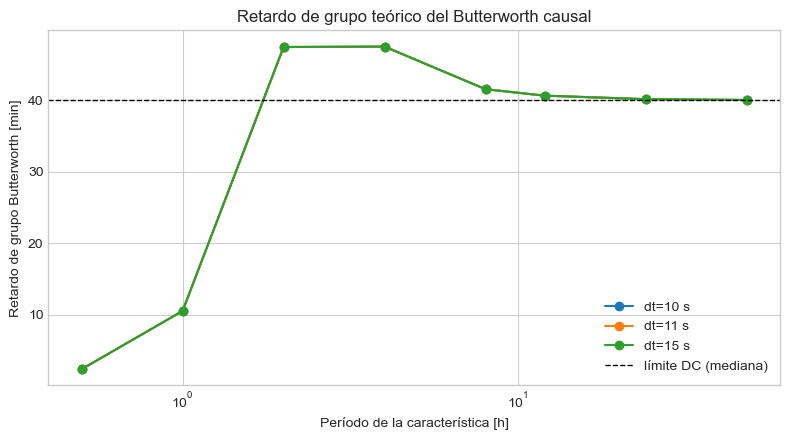

In [6]:
feature_period_hours = np.array([np.inf, 0.5, 1, 2, 4, 8, 12, 24, 48], dtype=float)
theory_rows = []
for dt in observed_periods:
    fs = 1.0 / dt
    wn = CUTOFF_HZ / (fs / 2.0)
    sos = signal.butter(BUTTER_ORDER, wn, btype="low", output="sos")
    b, a = signal.sos2tf(sos)
    for feature_h in feature_period_hours:
        frequency_hz = 0.0 if np.isinf(feature_h) else 1.0 / (feature_h * 3600.0)
        omega = max(1e-10, 2.0 * np.pi * frequency_hz / fs)
        _, gd_samples = signal.group_delay((b, a), w=np.array([omega]))
        theory_rows.append(
            {
                "sample_s": dt,
                "feature_period_h": feature_h,
                "frequency_hz": frequency_hz,
                "group_delay_samples": float(gd_samples[0]),
                "group_delay_s": float(gd_samples[0] * dt),
                "group_delay_min": float(gd_samples[0] * dt / 60.0),
            }
        )

theoretical_delay = pd.DataFrame(theory_rows)
theoretical_delay.to_csv(RESULTS / "theoretical_group_delay.csv", index=False)
display(theoretical_delay.round(4))

fig, ax = plt.subplots(figsize=(8, 4.5))
for dt, group in theoretical_delay[np.isfinite(theoretical_delay["feature_period_h"])].groupby("sample_s"):
    ax.plot(group["feature_period_h"], group["group_delay_min"], marker="o", label=f"dt={dt:g} s")
ax.axhline(
    theoretical_delay.loc[theoretical_delay["feature_period_h"].eq(np.inf), "group_delay_min"].median(),
    color="black", linestyle="--", linewidth=1, label="límite DC (mediana)"
)
ax.set_xscale("log")
ax.set_xlabel("Período de la característica [h]")
ax.set_ylabel("Retardo de grupo Butterworth [min]")
ax.set_title("Retardo de grupo teórico del Butterworth causal")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES / "theoretical_group_delay.png", dpi=160)
plt.show()
plt.close(fig)


## 3. Preparación de pares y estimadores

La interpolación se restringe a la superposición temporal de cada par. RAW y FILT se llevan a una grilla regular con el período mediano conjunto. No se altera la fuente.

La correlación se calcula como `correlate(FILT, RAW)`. Una prueba sintética incluida a continuación garantiza que una salida desplazada hacia el futuro produce lag positivo.


In [7]:
def read_signal(relative_path: str, role: str) -> pd.DataFrame:
    value_column = "flow_sccm" if role == "RAW" else "flow_filt_sccm"
    frame = pd.read_csv(RAW_ROOT / relative_path, usecols=["timestamp", value_column])
    frame = frame.rename(columns={value_column: "value"})
    frame["timestamp"] = pd.to_datetime(frame["timestamp"], errors="coerce")
    frame["value"] = pd.to_numeric(frame["value"], errors="coerce")
    return (
        frame.dropna(subset=["timestamp", "value"])
        .groupby("timestamp", as_index=False)["value"].mean()
        .sort_values("timestamp")
    )


def odd_window(seconds: float, dt_s: float, n: int, minimum: int = 5) -> int:
    value = max(minimum, int(round(seconds / dt_s)))
    if value % 2 == 0:
        value += 1
    maximum = n if n % 2 == 1 else n - 1
    return max(3, min(value, maximum))


def regularize_pair(pair: pd.Series) -> dict:
    raw = read_signal(pair["raw_file"], "RAW")
    filt = read_signal(pair["filt_file"], "FILT")
    start = max(raw["timestamp"].min(), filt["timestamp"].min())
    end = min(raw["timestamp"].max(), filt["timestamp"].max())

    dt_values = np.r_[
        raw["timestamp"].diff().dt.total_seconds().dropna(),
        filt["timestamp"].diff().dt.total_seconds().dropna(),
    ]
    dt_s = float(np.median(dt_values[dt_values > 0]))
    dt_s = float(max(1, round(dt_s)))
    grid = pd.date_range(start.ceil(f"{int(dt_s)}s"), end.floor(f"{int(dt_s)}s"), freq=f"{int(dt_s)}s")
    if len(grid) < 100:
        raise ValueError(f"Superposición insuficiente para {pair['lab_id']} {pair['segment']}")

    grid_ns = grid.view("int64")
    raw_values = np.interp(
        grid_ns,
        raw["timestamp"].astype("int64").to_numpy(),
        raw["value"].to_numpy(),
    )
    filt_values = np.interp(
        grid_ns,
        filt["timestamp"].astype("int64").to_numpy(),
        filt["value"].to_numpy(),
    )

    hampel_proxy_window = odd_window(W_SPIKE_SECONDS, dt_s, len(grid), minimum=3)
    raw_robust = (
        pd.Series(raw_values)
        .rolling(hampel_proxy_window, center=True, min_periods=1)
        .median()
        .to_numpy()
    )
    level_window = odd_window(15 * 60, dt_s, len(grid))
    derivative_window = odd_window(60 * 60, dt_s, len(grid))
    raw_level = signal.savgol_filter(raw_robust, level_window, polyorder=2)
    filt_level = signal.savgol_filter(filt_values, level_window, polyorder=2)
    raw_derivative_base = signal.savgol_filter(raw_robust, derivative_window, polyorder=2)
    filt_derivative_base = signal.savgol_filter(filt_values, derivative_window, polyorder=2)

    return {
        "time": grid,
        "dt_s": dt_s,
        "raw": raw_values,
        "filt": filt_values,
        "raw_robust": raw_robust,
        "raw_level": raw_level,
        "filt_level": filt_level,
        "raw_derivative": np.gradient(raw_derivative_base, dt_s),
        "filt_derivative": np.gradient(filt_derivative_base, dt_s),
    }


def cross_correlation(x: np.ndarray, y: np.ndarray, max_lag_samples: int) -> dict:
    # y representa FILT. correlate(y, x) da lag positivo si y está retrasada.
    x = signal.detrend(np.asarray(x, dtype=float))
    y = signal.detrend(np.asarray(y, dtype=float))
    x = (x - x.mean()) / (x.std() + 1e-12)
    y = (y - y.mean()) / (y.std() + 1e-12)
    corr = signal.correlate(y, x, mode="full", method="fft")
    lags = signal.correlation_lags(len(y), len(x), mode="full")
    keep = np.abs(lags) <= max_lag_samples
    lags = lags[keep]
    corr = corr[keep] / len(x)
    best = int(np.argmax(corr))
    return {
        "lag_samples": int(lags[best]),
        "correlation": float(corr[best]),
        "lags": lags,
        "curve": corr,
    }


# Validación inequívoca de la convención de signo.
synthetic_raw = np.zeros(200)
synthetic_filt = np.zeros(200)
synthetic_raw[50] = 1.0
synthetic_filt[63] = 1.0
_sign_test = cross_correlation(synthetic_raw, synthetic_filt, max_lag_samples=30)
assert _sign_test["lag_samples"] == 13
print("Prueba de signo correcta: desplazamiento sintético = +13 muestras.")


Prueba de signo correcta: desplazamiento sintético = +13 muestras.


In [8]:
preliminary_rows = []
pair_cache = {}
for index, pair in pairs[pairs["complete"]].iterrows():
    prepared = regularize_pair(pair)
    pair_cache[index] = prepared
    max_lag = int(round(3 * 3600 / prepared["dt_s"]))
    level = cross_correlation(prepared["raw_level"], prepared["filt_level"], max_lag)
    derivative = cross_correlation(prepared["raw_derivative"], prepared["filt_derivative"], max_lag)
    amplitude = float(
        np.percentile(prepared["raw_robust"], 95)
        - np.percentile(prepared["raw_robust"], 5)
    )
    preliminary_rows.append(
        {
            "pair_index": index,
            "amplitude_p95_p05_sccm": amplitude,
            "level_lag_min_preliminary": level["lag_samples"] * prepared["dt_s"] / 60.0,
            "level_correlation_preliminary": level["correlation"],
            "derivative_lag_min_preliminary": derivative["lag_samples"] * prepared["dt_s"] / 60.0,
            "derivative_correlation_preliminary": derivative["correlation"],
        }
    )

preliminary = pd.DataFrame(preliminary_rows).set_index("pair_index")
pairs = pairs.join(preliminary)
pairs["eligible"] = (
    pairs["complete"]
    & pairs["sample_compatible"]
    & pairs["invalid_timestamps"].eq(0)
    & pairs["overlap_h"].ge(12)
    & pairs["amplitude_p95_p05_sccm"].ge(0.5)
    & pairs["level_correlation_preliminary"].ge(0.5)
    & pairs["level_lag_min_preliminary"].between(0, 120)
)
pairs["representative_score"] = (
    np.log1p(pairs["overlap_h"])
    * pairs["amplitude_p95_p05_sccm"].clip(lower=0)
    * pairs["level_correlation_preliminary"].clip(lower=0)
)
pairs["selected"] = False
for lab_id, group in pairs[pairs["eligible"]].groupby("lab_id"):
    pairs.loc[group["representative_score"].idxmax(), "selected"] = True

def exclusion_reason(row: pd.Series) -> str:
    if row["selected"]:
        return "selected"
    reasons = []
    if not row["complete"]:
        reasons.append("missing RAW or FILT")
    if row["overlap_h"] < 12:
        reasons.append("overlap < 12 h")
    if not row["sample_compatible"]:
        reasons.append("incompatible sample periods")
    if row["invalid_timestamps"] > 0:
        reasons.append("invalid timestamps")
    if row["amplitude_p95_p05_sccm"] < 0.5:
        reasons.append("insufficient dynamic amplitude")
    if row["level_correlation_preliminary"] < 0.5:
        reasons.append("weak level correlation")
    if not (0 <= row["level_lag_min_preliminary"] <= 120):
        reasons.append("nonphysical/unstable preliminary lag")
    if row["eligible"] and not row["selected"]:
        reasons.append("another segment better represents this experiment")
    return "; ".join(reasons) if reasons else "not selected"

pairs["selection_status"] = pairs.apply(exclusion_reason, axis=1)
pairs.to_csv(RESULTS / "paired_files.csv", index=False)

print(f"Pares completos: {pairs['complete'].sum()}")
print(f"Segmentos elegibles: {pairs['eligible'].sum()}")
print(f"Experimentos representativos seleccionados: {pairs['selected'].sum()}")
display(
    pairs[
        [
            "lab_id", "fermenter", "segment", "overlap_h", "raw_sample_s",
            "filt_sample_s", "amplitude_p95_p05_sccm",
            "level_lag_min_preliminary", "level_correlation_preliminary",
            "selected", "selection_status",
        ]
    ].round(3)
)


Pares completos: 24
Segmentos elegibles: 15
Experimentos representativos seleccionados: 12


,lab_id,fermenter,segment,overlap_h,raw_sample_s,filt_sample_s,amplitude_p95_p05_sccm,level_lag_min_preliminary,level_correlation_preliminary,selected,selection_status
0,lab001,F1,28_03_26_1700,26.153,10.0,10.0,10.018,45.000,0.690,True,selected
1,lab001,F1,pt2,16.087,10.0,10.0,7.566,33.333,0.910,False,another segment better represents this experiment
2,lab001,F1,pt3,44.967,10.0,10.0,0.000,43.333,0.418,False,insufficient dynamic amplitude; weak level cor...
3,lab002,F2,29_03_26_1700,1.156,10.0,10.0,1.458,-45.667,0.316,False,overlap < 12 h; weak level correlation; nonphy...
4,lab002,F2,pt2,16.067,10.0,10.0,3.187,40.833,0.644,False,another segment better represents this experiment
5,lab002,F2,pt3,44.958,10.0,10.0,5.066,37.167,0.696,True,selected
6,lab003,F3,29_03_26_1700,1.159,10.0,10.0,0.529,-33.500,0.540,False,overlap < 12 h; nonphysical/unstable prelimina...
7,lab003,F3,pt2,16.067,10.0,10.0,0.968,41.333,0.426,False,weak level correlation
8,lab003,F3,pt3,44.953,10.0,10.0,1.634,41.000,0.598,True,selected
9,lab004,F1,main,16.443,10.0,10.0,0.000,43.500,0.359,False,insufficient dynamic amplitude; weak level cor...


## 4. Retardos experimentales

Además de las dos correlaciones se calculan:

- t10/t50/t90 sobre la subida hacia un máximo interior claro, normalizando cada señal por su propio rango robusto;
- desplazamiento del máximo sobre las curvas suavizadas;
- RMSE antes y después de compensar el lag de niveles;
- retardos por ventanas. Se usan ventanas de 24 h en segmentos largos y 8 h en segmentos más cortos.

Los tiempos característicos quedan como NaN si la señal no presenta una subida y un máximo suficientemente claros; esto evita inventar hitos en segmentos planos o que comienzan a mitad de fermentación.


In [9]:
def align_for_lag(raw: np.ndarray, filt: np.ndarray, lag: int):
    if lag > 0:
        return raw[:-lag], filt[lag:]
    if lag < 0:
        return raw[-lag:], filt[:lag]
    return raw, filt


def first_sustained_crossing(values, threshold, stop_index, dt_s, hold_min=30.0):
    """Primer cruce que permanece sobre el umbral durante al menos 30 min."""
    hold = max(3, int(round(hold_min * 60.0 / dt_s)))
    flags = np.asarray(values[: stop_index + 1] >= threshold, dtype=int)
    if len(flags) < hold:
        return np.nan
    persistence = np.convolve(flags, np.ones(hold, dtype=int), mode="valid")
    crossings = np.flatnonzero(persistence >= int(math.ceil(0.9 * hold)))
    return float(crossings[0] * dt_s / 60.0) if len(crossings) else np.nan


def characteristic_delays(raw_values, filt_values, dt_s, max_event_delay_min=180.0):
    """t10/t50/t90 con umbrales RAW compartidos y máximo del mismo evento."""
    n = len(raw_values)
    baseline = float(np.median(raw_values[: max(10, n // 20)]))
    raw_peak_index = int(np.argmax(raw_values))
    filt_peak_index = int(np.argmax(filt_values))
    raw_peak = float(raw_values[raw_peak_index])
    robust_range = float(np.percentile(raw_values, 95) - np.percentile(raw_values, 5))
    noise = float(1.4826 * np.median(np.abs(np.diff(raw_values) - np.median(np.diff(raw_values)))))
    clear_raw_peak = (
        0.05 * n < raw_peak_index < 0.95 * n
        and (raw_peak - baseline) >= max(0.5, 0.5 * robust_range, 8.0 * noise)
    )
    peak_delay = (filt_peak_index - raw_peak_index) * dt_s / 60.0
    same_event = clear_raw_peak and 0.0 <= peak_delay <= max_event_delay_min
    result = {f"t{threshold}_delay_min": np.nan for threshold in (10, 50, 90)}
    result["peak_delay_min"] = peak_delay if same_event else np.nan
    if not same_event:
        return result

    for fraction in (0.1, 0.5, 0.9):
        threshold = baseline + fraction * (raw_peak - baseline)
        raw_time = first_sustained_crossing(raw_values, threshold, raw_peak_index, dt_s)
        filt_time = first_sustained_crossing(filt_values, threshold, filt_peak_index, dt_s)
        delay = filt_time - raw_time if np.isfinite(raw_time) and np.isfinite(filt_time) else np.nan
        if np.isfinite(delay) and 0.0 <= delay <= max_event_delay_min:
            result[f"t{int(fraction * 100)}_delay_min"] = delay
    return result


def window_delays(prepared: dict, lab_id: str, fermenter: str, segment: str) -> list[dict]:
    dt_s = prepared["dt_s"]
    n = len(prepared["time"])
    total_h = n * dt_s / 3600.0
    window_h = 24.0 if total_h >= 72 else 8.0
    window_n = int(round(window_h * 3600 / dt_s))
    step_n = max(1, window_n // 2)
    max_lag = int(round(2 * 3600 / dt_s))
    overall_amplitude = np.percentile(prepared["raw_robust"], 95) - np.percentile(prepared["raw_robust"], 5)
    records = []

    if n < window_n:
        return records
    for start in range(0, n - window_n + 1, step_n):
        stop = start + window_n
        raw_window = prepared["raw_level"][start:stop]
        filt_window = prepared["filt_level"][start:stop]
        amplitude = float(np.percentile(raw_window, 95) - np.percentile(raw_window, 5))
        if amplitude < max(0.2, 0.05 * overall_amplitude):
            continue
        level = cross_correlation(raw_window, filt_window, max_lag)
        derivative = cross_correlation(
            prepared["raw_derivative"][start:stop],
            prepared["filt_derivative"][start:stop],
            max_lag,
        )
        if level["correlation"] < 0.25:
            continue
        records.append(
            {
                "lab_id": lab_id,
                "fermenter": fermenter,
                "segment": segment,
                "window_start": prepared["time"][start],
                "window_end": prepared["time"][stop - 1],
                "window_h": window_h,
                "amplitude_sccm": amplitude,
                "level_lag_min": level["lag_samples"] * dt_s / 60.0,
                "level_correlation": level["correlation"],
                "derivative_lag_min": derivative["lag_samples"] * dt_s / 60.0,
                "derivative_correlation": derivative["correlation"],
            }
        )
    return records


delay_rows = []
window_rows = []
analysis_cache = {}

for index, pair in pairs[pairs["selected"]].sort_values("lab_number").iterrows():
    prepared = pair_cache[index]
    dt_s = prepared["dt_s"]
    max_lag = int(round(3 * 3600 / dt_s))
    level = cross_correlation(prepared["raw_level"], prepared["filt_level"], max_lag)
    derivative = cross_correlation(prepared["raw_derivative"], prepared["filt_derivative"], max_lag)
    level_lag = level["lag_samples"]
    derivative_lag = derivative["lag_samples"]

    raw_aligned, filt_aligned = align_for_lag(
        prepared["raw_level"], prepared["filt_level"], level_lag
    )
    raw_unaligned, filt_unaligned = align_for_lag(
        prepared["raw_level"], prepared["filt_level"], 0
    )
    rmse_before = float(np.sqrt(np.mean((raw_unaligned - filt_unaligned) ** 2)))
    rmse_after = float(np.sqrt(np.mean((raw_aligned - filt_aligned) ** 2)))
    corr_after = float(np.corrcoef(raw_aligned, filt_aligned)[0, 1])

    characteristic = characteristic_delays(
        prepared["raw_level"], prepared["filt_level"], dt_s
    )
    peak_delay = characteristic.pop("peak_delay_min")

    delay_rows.append(
        {
            "lab_id": pair["lab_id"],
            "fermenter": pair["fermenter"],
            "segment": pair["segment"],
            "raw_file": pair["raw_file"],
            "filt_file": pair["filt_file"],
            "overlap_h": pair["overlap_h"],
            "sample_s": dt_s,
            "amplitude_p95_p05_sccm": pair["amplitude_p95_p05_sccm"],
            "level_lag_samples": level_lag,
            "level_delay_s": level_lag * dt_s,
            "level_delay_min": level_lag * dt_s / 60.0,
            "level_correlation": level["correlation"],
            "derivative_lag_samples": derivative_lag,
            "derivative_delay_s": derivative_lag * dt_s,
            "derivative_delay_min": derivative_lag * dt_s / 60.0,
            "derivative_correlation": derivative["correlation"],
            **characteristic,
            "peak_delay_min": peak_delay,
            "rmse_before_sccm": rmse_before,
            "rmse_after_compensation_sccm": rmse_after,
            "correlation_after_compensation": corr_after,
        }
    )
    window_rows.extend(
        window_delays(
            prepared, pair["lab_id"], pair["fermenter"], pair["segment"]
        )
    )
    analysis_cache[pair["lab_id"]] = {
        "pair": pair,
        "prepared": prepared,
        "level": level,
        "derivative": derivative,
    }

delay_summary = pd.DataFrame(delay_rows).sort_values("lab_id").reset_index(drop=True)
window_summary = pd.DataFrame(window_rows)
delay_summary.to_csv(RESULTS / "delay_summary.csv", index=False)
window_summary.to_csv(RESULTS / "window_delay_summary.csv", index=False)

display(delay_summary.round(3))


,lab_id,fermenter,segment,raw_file,filt_file,overlap_h,sample_s,amplitude_p95_p05_sccm,level_lag_samples,level_delay_s,level_delay_min,level_correlation,derivative_lag_samples,derivative_delay_s,derivative_delay_min,derivative_correlation,t10_delay_min,t50_delay_min,t90_delay_min,peak_delay_min,rmse_before_sccm,rmse_after_compensation_sccm,correlation_after_compensation
0,lab001,F1,28_03_26_1700,CO2_lab001_28_03_26_1700.csv,CO2_FILT_lab001_28_03_26_1700.csv,26.153,10.0,10.018,270,2700.0,45.000,0.690,251,2510.0,41.833,0.410,17.833,NaN,NaN,24.833,2.356,1.712,0.797
1,lab002,F2,pt3,CO2_F2_lab002_pt3.csv,CO2_FILT_F2_lab002_pt3.csv,44.958,10.0,5.066,223,2230.0,37.167,0.696,242,2420.0,40.333,0.464,NaN,NaN,NaN,40.333,1.258,0.882,0.867
2,lab003,F3,pt3,Desktop_CyT_Tablero_Proceso\CO2_F3_lab003_pt3.csv,Desktop_CyT_Tablero_Proceso\CO2_FILT_F3_lab003...,44.953,10.0,1.634,246,2460.0,41.000,0.598,246,2460.0,41.000,0.477,0.000,NaN,NaN,45.167,0.779,0.544,0.727
3,lab004,F1,pt2,CO2_F1_LAB004_PT2.csv,CO2_FILT_F1_LAB004_PT2.csv,171.269,10.0,12.535,255,2550.0,42.500,0.894,254,2540.0,42.333,0.555,NaN,NaN,NaN,NaN,2.691,1.784,0.936
4,lab005,F2,pt2,CO2_F2_LAB005_PT2.csv,CO2_FILT_F2_LAB005_PT2.csv,171.274,10.0,10.815,233,2330.0,38.833,0.907,253,2530.0,42.167,0.477,NaN,NaN,NaN,NaN,1.465,1.099,0.964
5,lab006,F3,pt2,CO2_F3_LAB006_PT2.csv,CO2_FILT_F3_LAB006_PT2.csv,194.256,10.0,6.548,257,2570.0,42.833,0.907,251,2510.0,41.833,0.481,2.167,NaN,NaN,24.167,1.219,0.881,0.928
6,lab007,F1,main,CO2_F1_lab007.csv,CO2_FILT_F1_lab007.csv,166.277,11.0,13.585,279,3069.0,51.150,0.960,258,2838.0,47.300,0.498,NaN,NaN,NaN,NaN,2.360,1.387,0.966
7,lab008,F2,main,CO2_F2_lab008.csv,CO2_FILT_F2_lab008.csv,166.271,11.0,10.788,278,3058.0,50.967,0.955,255,2805.0,46.750,0.489,NaN,NaN,NaN,NaN,1.936,1.147,0.960
8,lab009,F3,main,CO2_F3_lab009.csv,CO2_FILT_F3_lab009.csv,166.266,11.0,4.504,300,3300.0,55.000,0.872,270,2970.0,49.500,0.399,NaN,NaN,NaN,NaN,1.380,0.870,0.874
9,lab010,F1,pt2,CO2_F1_lab10_PT2.csv,CO2_FILT_F1_lab10_PT2.csv,210.677,15.0,6.075,202,3030.0,50.500,0.955,190,2850.0,47.500,0.320,NaN,NaN,NaN,NaN,0.756,0.631,0.958


### 4.1 Pulsos de nitrógeno en las figuras (LAB004–LAB012)

Para leer los retardos en el contexto del proceso, las figuras RAW vs FILT de esta sección marcan el **pulso 2 de nitrógeno** según las dos convenciones caracterizadas en el repositorio:

- **Pulso_nut planilla (upstream)** — línea **verde continua**: columna `pulso_nut` del workbook `mosto_natural_xthiol.xlsx` (tiempo = columna `t` de la fila; dosis 80 mg/L). Es el pulso que consume el modelo cinético.
- **Cruce densidad 1040 (capa CO2)** — línea **roja discontinua**: tiempo efectivo que aplica la capa CO2 (`effective_nutrient_pulses.csv` de la corrida congelada; `timing_source` = cruce de densidad; dosis 0.14 kg/m³).

Ambos se llevan al eje temporal de la figura vía el `t=0` del lote (fila `t == 0` del workbook), el mismo origen que usan ambos pipelines, por lo que la comparación es directa. LAB001–LAB003 no tienen hojas de química homologada ni registro de pulso: sus figuras no llevan líneas. Si un pulso cae fuera de la superposición del segmento, la línea no es visible pero permanece en la leyenda. Esta superposición es solo contextual: no modifica el cálculo de retardos ni interpreta el pulso en sí.

In [10]:
# Pulsos de nitrogeno (LAB004-LAB012) segun las dos convenciones caracterizadas en el repositorio.
# - Pulso_nut planilla (upstream): columna `pulso_nut` del workbook, tiempo = columna `t` de la fila, dosis 80 mg/L.
# - Cruce densidad 1040 (capa CO2): tiempo efectivo de la corrida congelada (`effective_nutrient_pulses.csv`), dosis 0.14 kg/m3.
# Ambos se llevan a timestamp absoluto via el t=0 del lote (fila `t == 0` del workbook), el mismo origen de ambos pipelines.

WORKBOOK_NATURAL = FM_ROOT / "data" / "Laboratorio 2026" / "Vendimia_2026" / "mosto_natural_xthiol.xlsx"
NORM_CACHE = FM_ROOT / "shared" / "results" / "new_must_data_loading" / "new_must_normalized_long.csv"
CO2_PULSES = (
    FM_ROOT / "laboratory_2026" / "results"
    / "co2_matrix_cross_validation_2026_full_theta_sccm_corrected_no_lab010"
    / "effective_nutrient_pulses.csv"
)

NATURAL_LABS = [f"LAB{number:03d}" for number in range(4, 13)]
pulse_t0 = {}
for lab in NATURAL_LABS:
    sheet = pd.read_excel(WORKBOOK_NATURAL, sheet_name=lab)
    t_num = pd.to_numeric(sheet["t"], errors="coerce")
    zero = sheet[t_num.eq(0.0)]
    pulse_t0[lab] = pd.to_datetime(zero["fecha_hora"].iloc[0])

norm_cache = pd.read_csv(NORM_CACHE)
upstream_rows = norm_cache[norm_cache["N_pulse_mg_l"].fillna(0.0) > 0.0]
upstream_pulse_h = dict(zip(upstream_rows["batch"], upstream_rows["time_h"]))

eff = pd.read_csv(CO2_PULSES)
co2_pulse_h = dict(zip(eff["batch"], eff["pulse_time_h"]))
co2_timing_source = dict(zip(eff["batch"], eff["timing_source"]))

pulse_rows = []
for lab in NATURAL_LABS:
    pulse_rows.append({
        "batch": lab,
        "t0_batch": pulse_t0[lab],
        "t_pulse_upstream_h": upstream_pulse_h[lab],
        "t_pulse_upstream_abs": pulse_t0[lab] + pd.Timedelta(hours=float(upstream_pulse_h[lab])),
        "t_pulse_CO2_h": co2_pulse_h[lab],
        "t_pulse_CO2_abs": pulse_t0[lab] + pd.Timedelta(hours=float(co2_pulse_h[lab])),
        "timing_source_CO2": co2_timing_source[lab],
    })
natural_pulses = pd.DataFrame(pulse_rows)
display(natural_pulses)
print("LAB001-LAB003: sin hojas de química homologada en el workbook -> sin registro de pulso (sus figuras no llevan líneas).")

,batch,t0_batch,t_pulse_upstream_h,t_pulse_upstream_abs,t_pulse_CO2_h,t_pulse_CO2_abs,timing_source_CO2
0,LAB004,2026-04-06 13:00:00,68.0,2026-04-09 09:00:00,56.091667,2026-04-08 21:05:29.999999999,chemical_density_linear_interpolation
1,LAB005,2026-04-06 13:00:00,68.0,2026-04-09 09:00:00,55.086614,2026-04-08 20:05:11.811023621,chemical_density_linear_interpolation
2,LAB006,2026-04-06 13:00:00,99.0,2026-04-10 16:00:00,74.000000,2026-04-09 15:00:00.000000000,chemical_density_linear_interpolation
3,LAB007,2026-04-17 16:00:00,65.0,2026-04-20 09:00:00,56.246154,2026-04-20 00:14:46.153846154,chemical_density_linear_interpolation
4,LAB008,2026-04-17 16:00:00,65.0,2026-04-20 09:00:00,56.750000,2026-04-20 00:45:00.000000000,chemical_density_linear_interpolation
5,LAB009,2026-04-17 16:00:00,41.0,2026-04-19 09:00:00,41.846154,2026-04-19 09:50:46.153846154,chemical_density_linear_interpolation
6,LAB010,2026-05-12 15:00:00,79.0,2026-05-15 22:00:00,102.494530,2026-05-16 21:29:40.306345637,chemical_density_linear_interpolation_sparse_b...
7,LAB011,2026-05-12 15:00:00,72.0,2026-05-15 15:00:00,86.836735,2026-05-16 05:50:12.244897749,chemical_density_linear_interpolation_sparse_b...
8,LAB012,2026-05-12 15:00:00,72.0,2026-05-15 15:00:00,91.041739,2026-05-16 10:02:30.260869355,chemical_density_linear_interpolation_sparse_b...


LAB001-LAB003: sin hojas de química homologada en el workbook -> sin registro de pulso (sus figuras no llevan líneas).


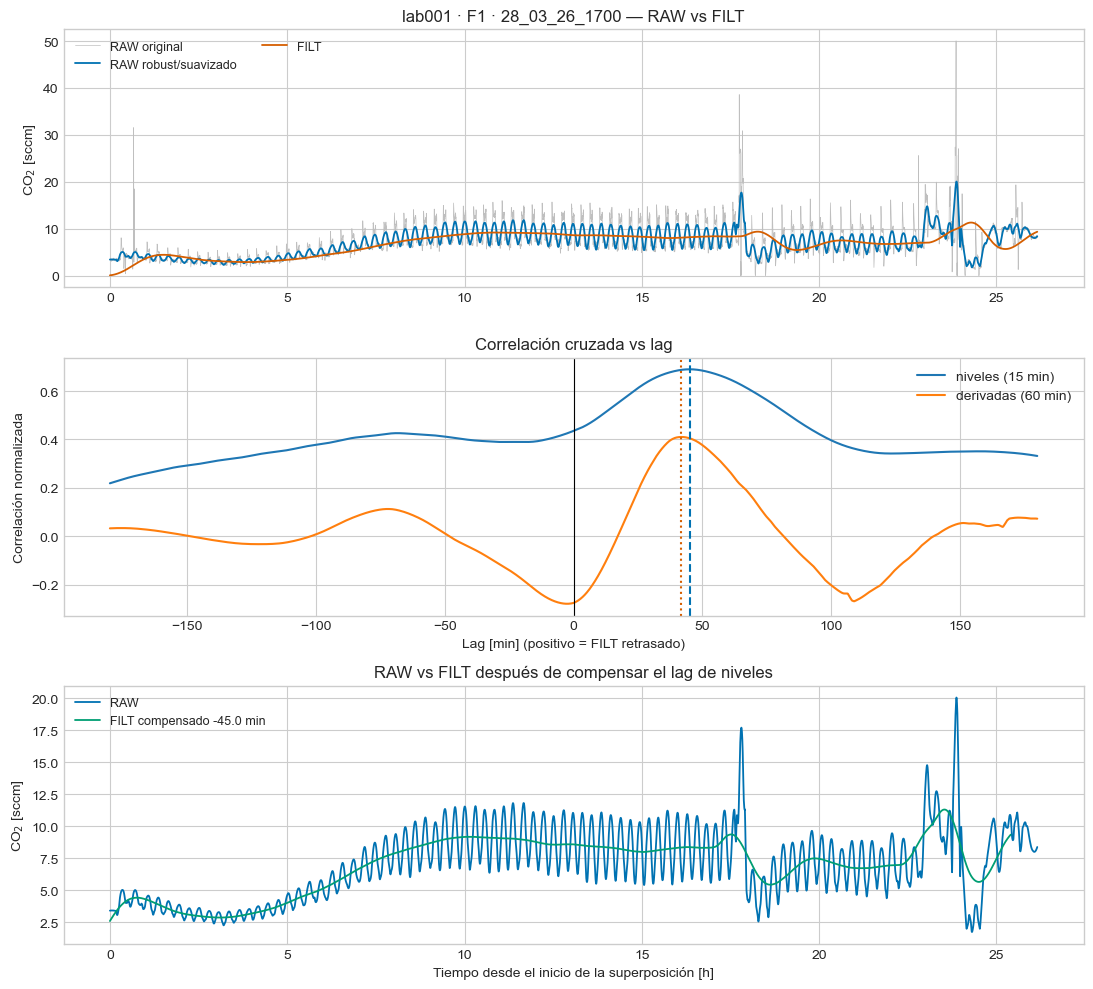

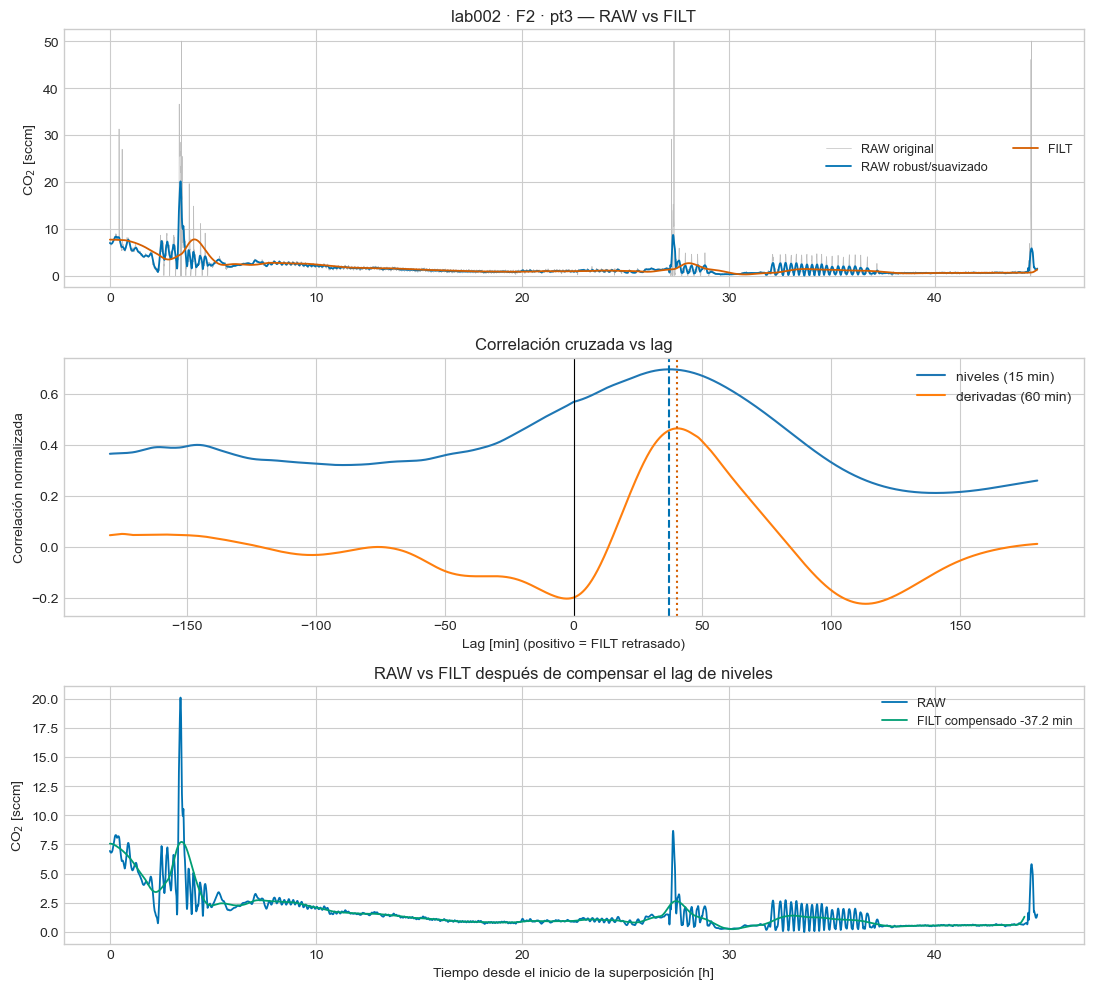

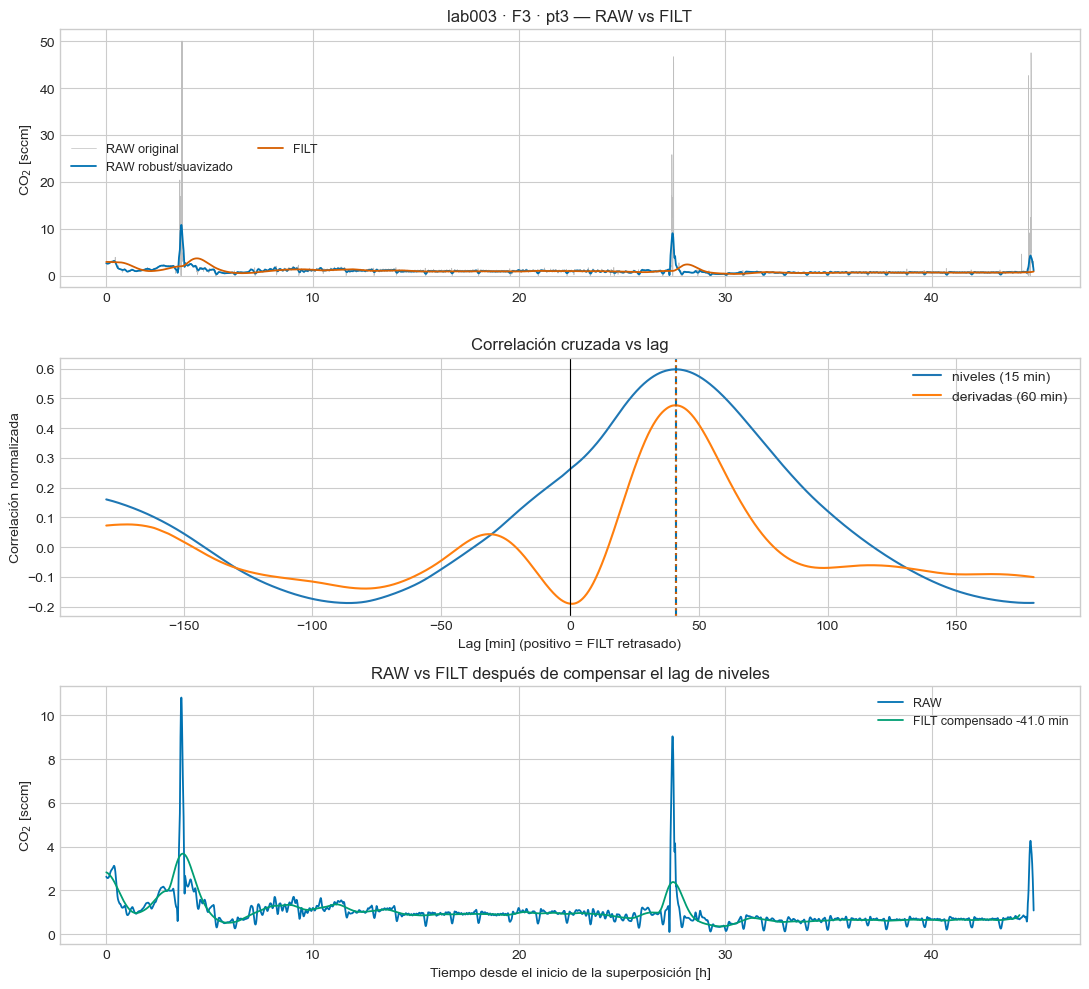

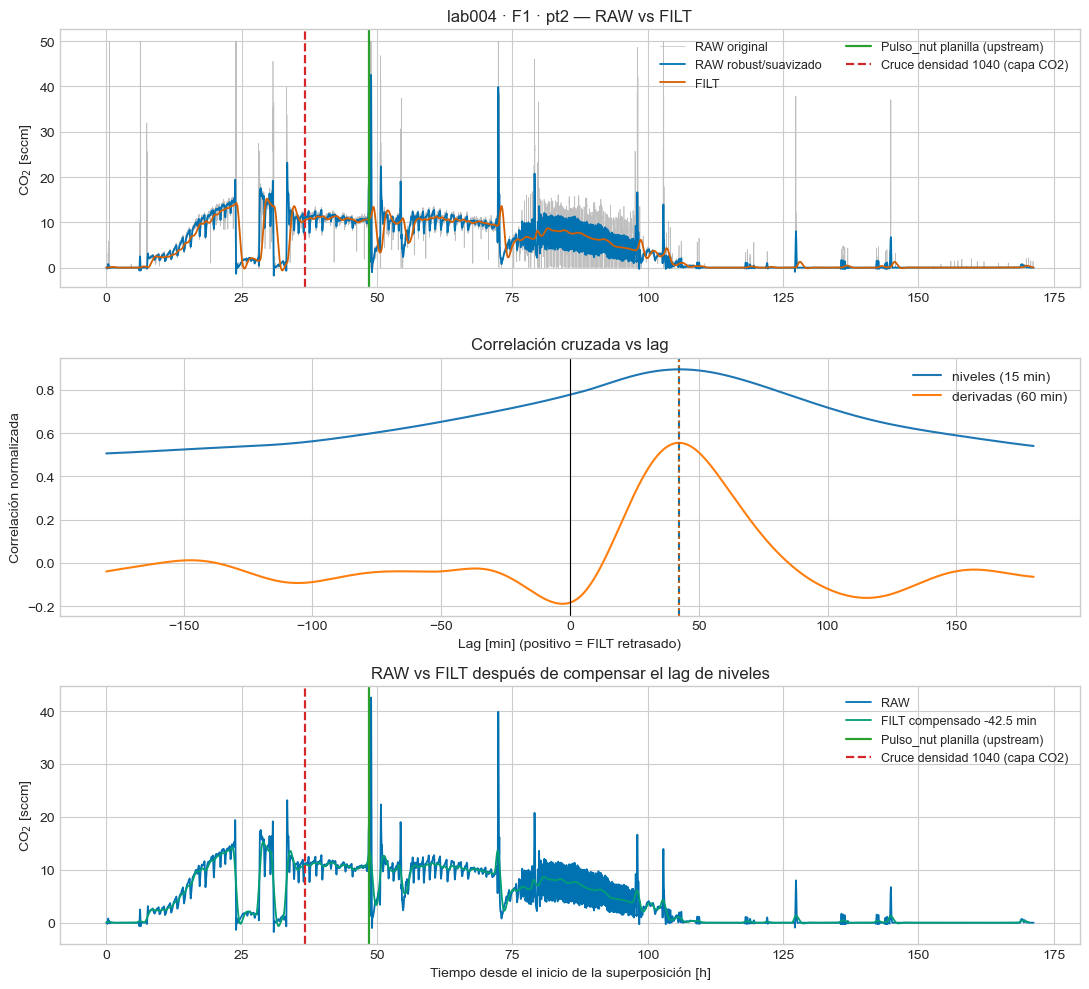

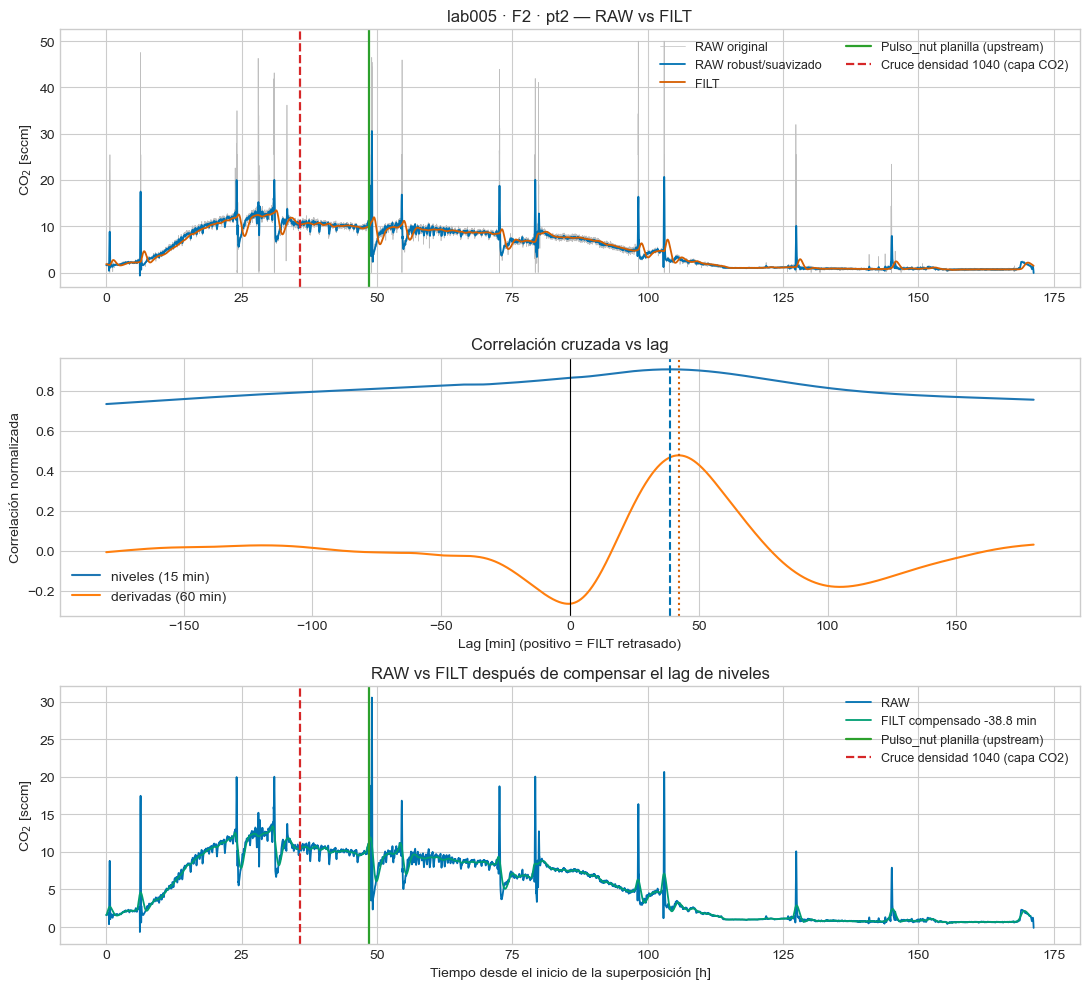

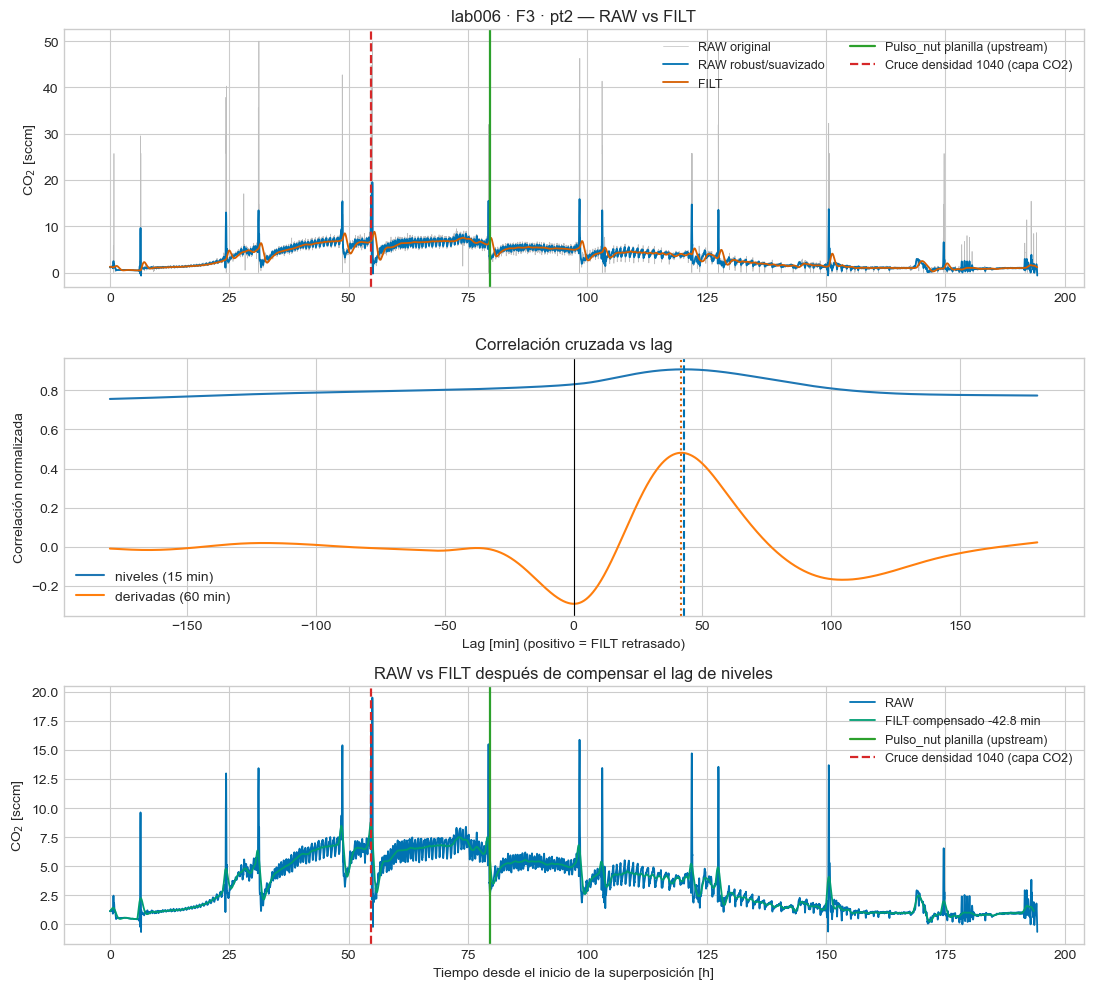

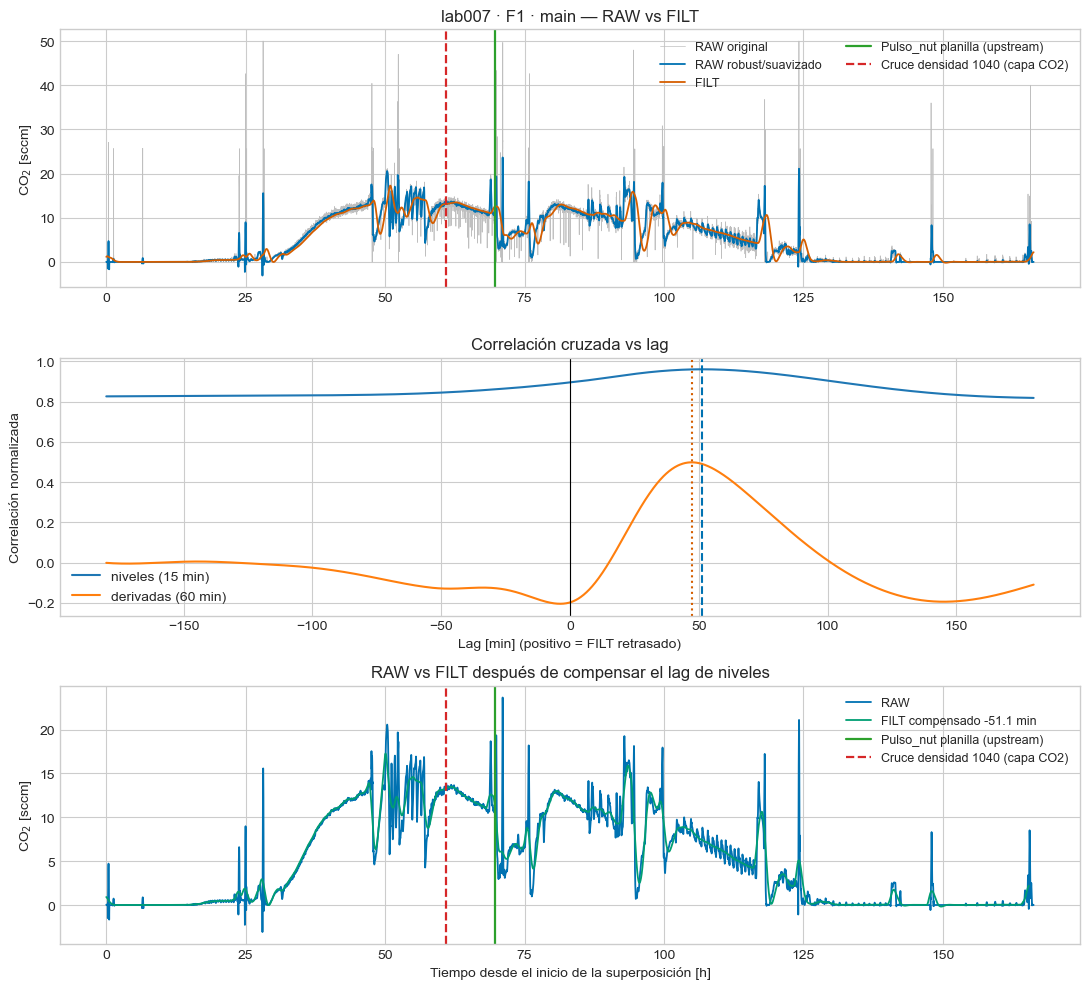

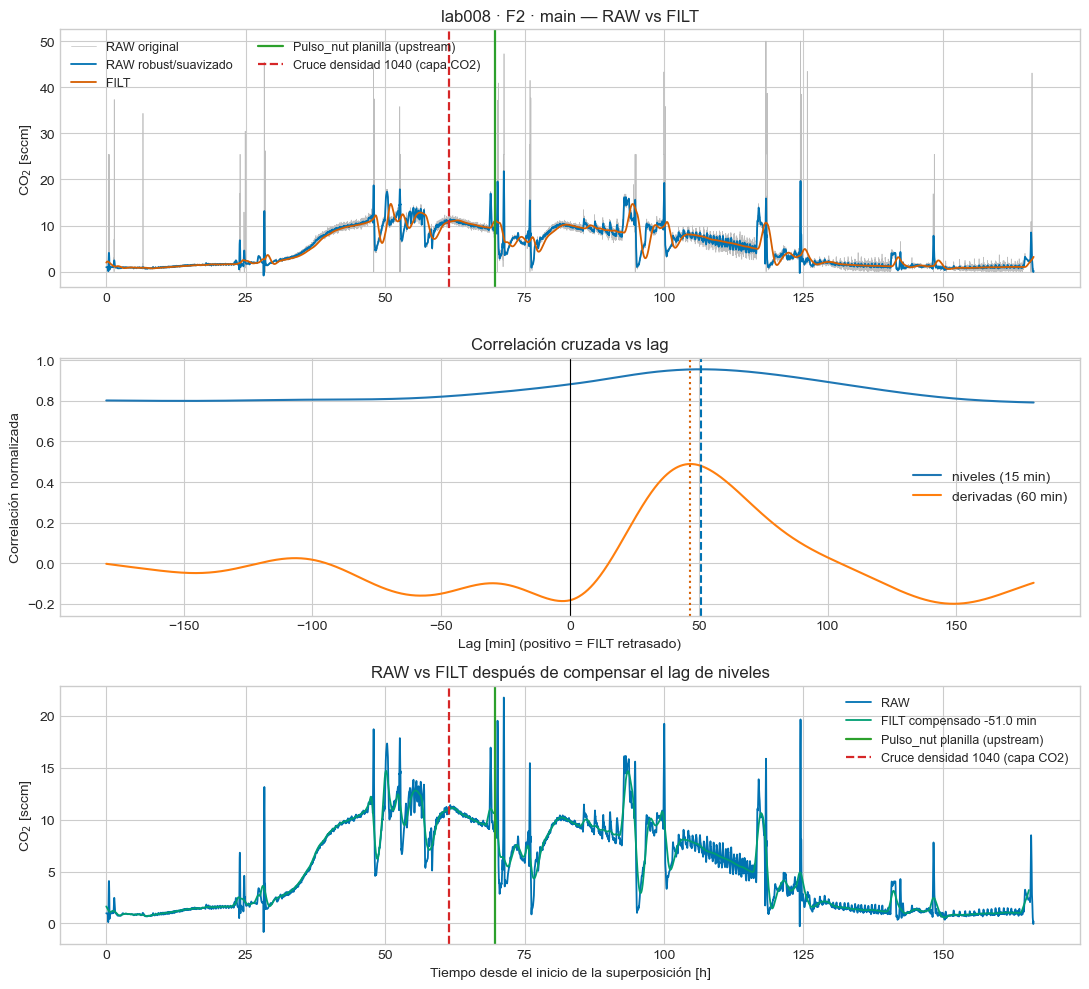

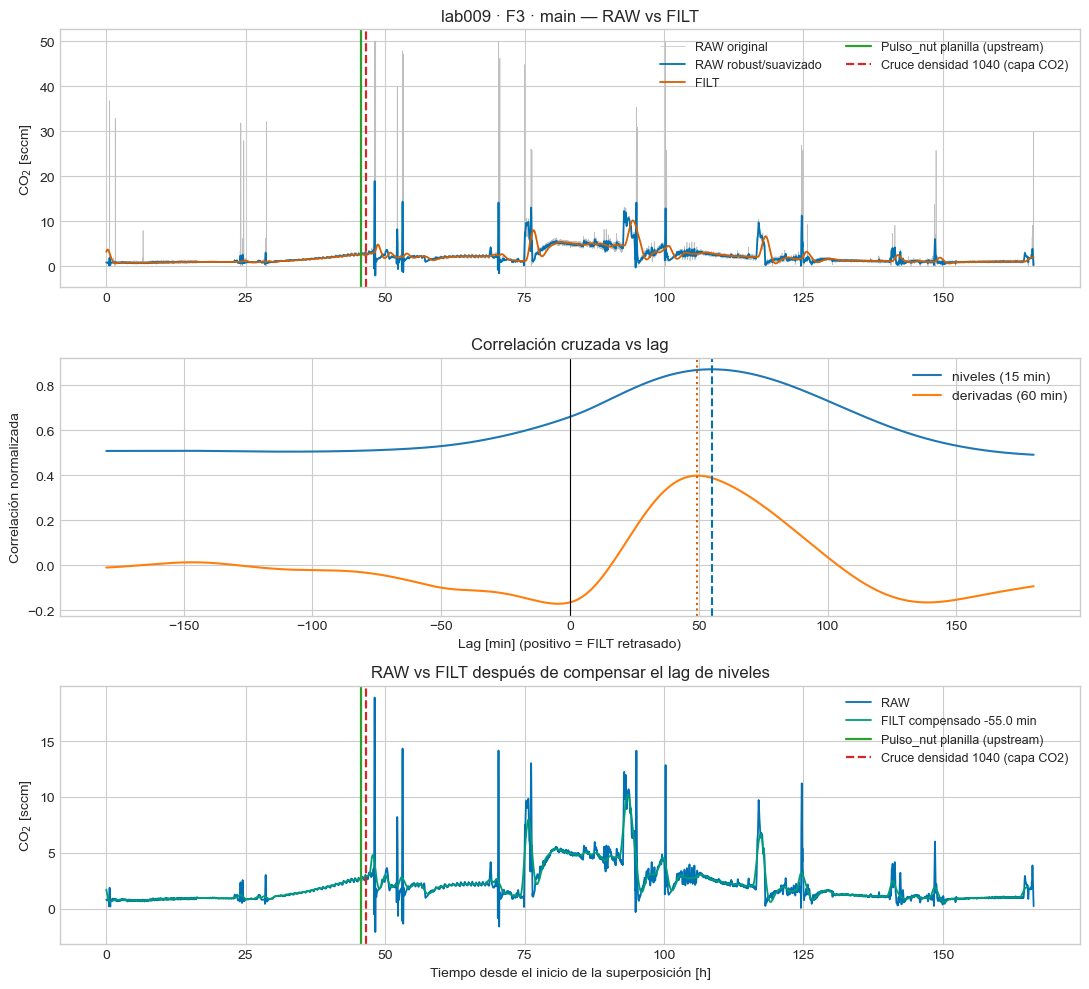

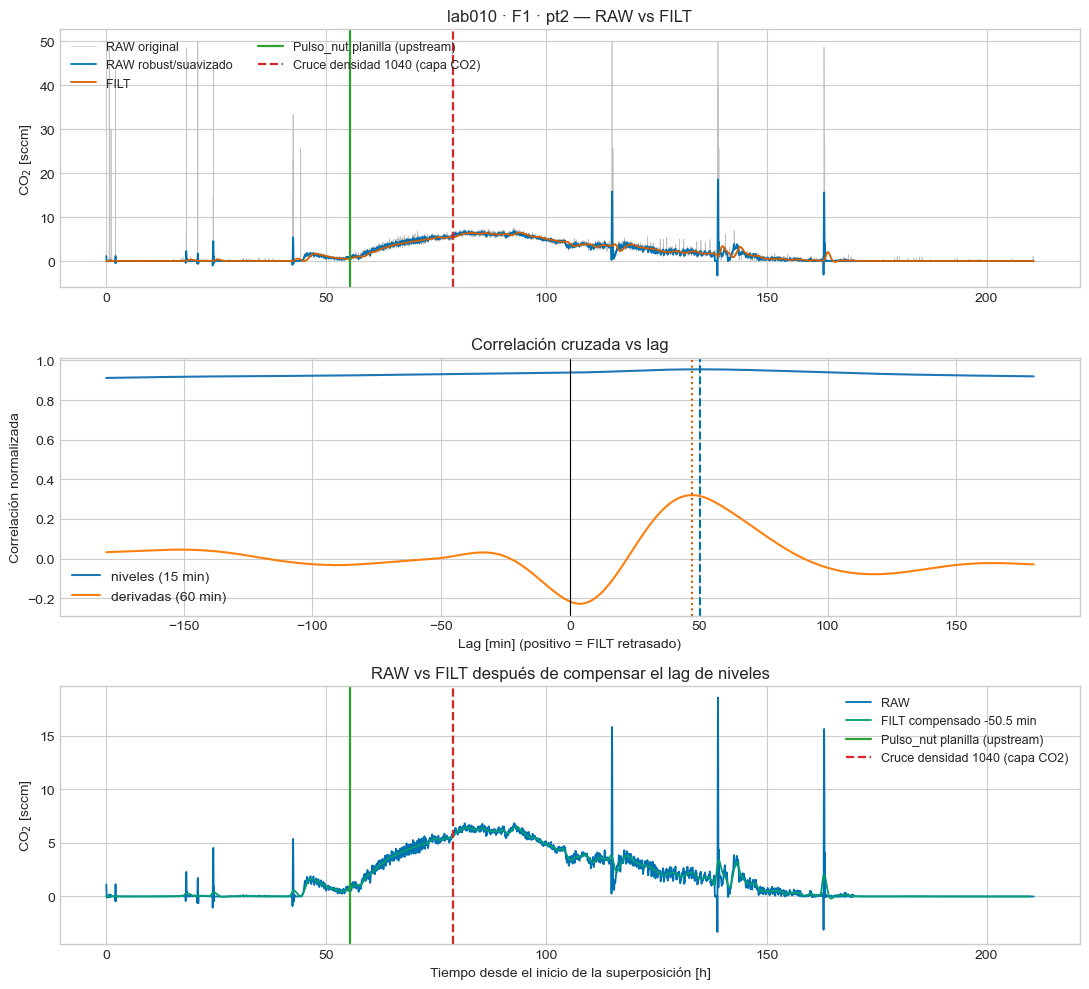

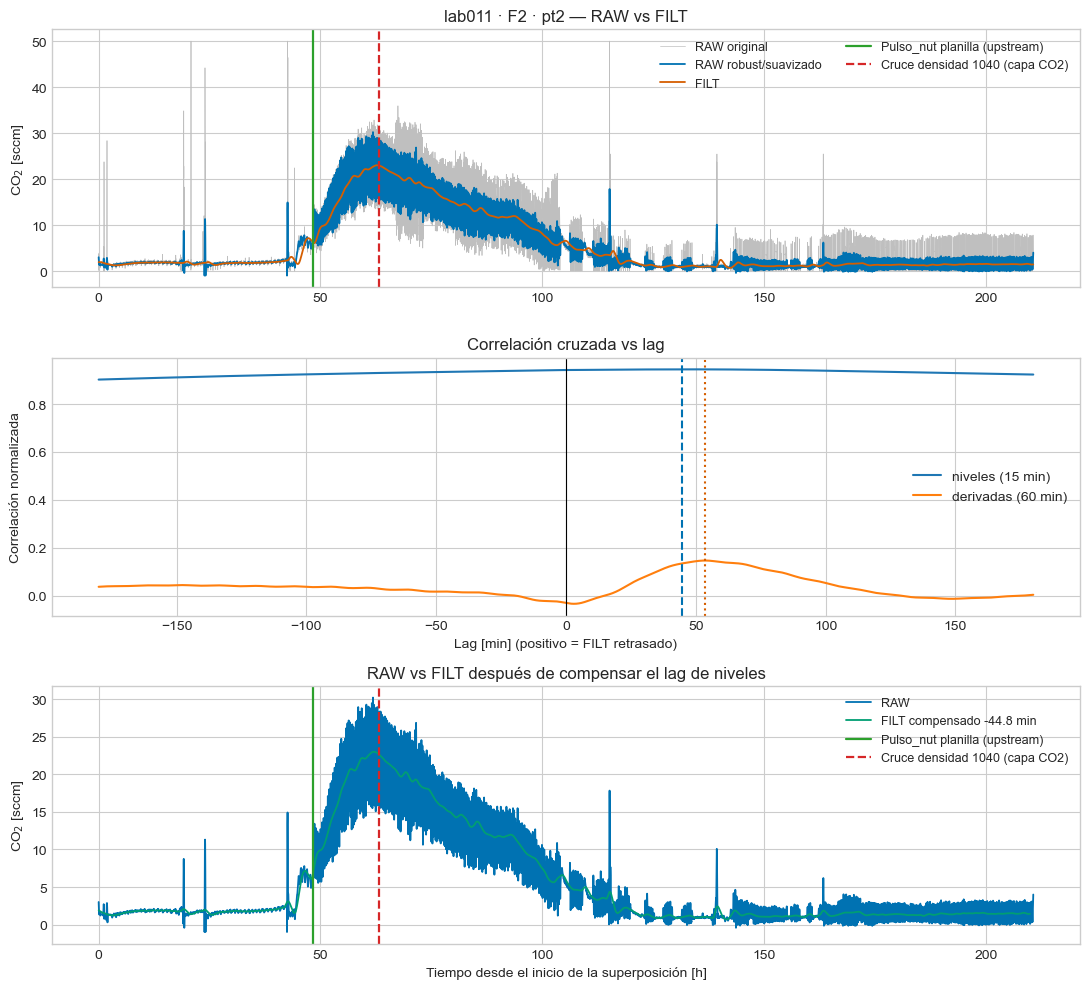

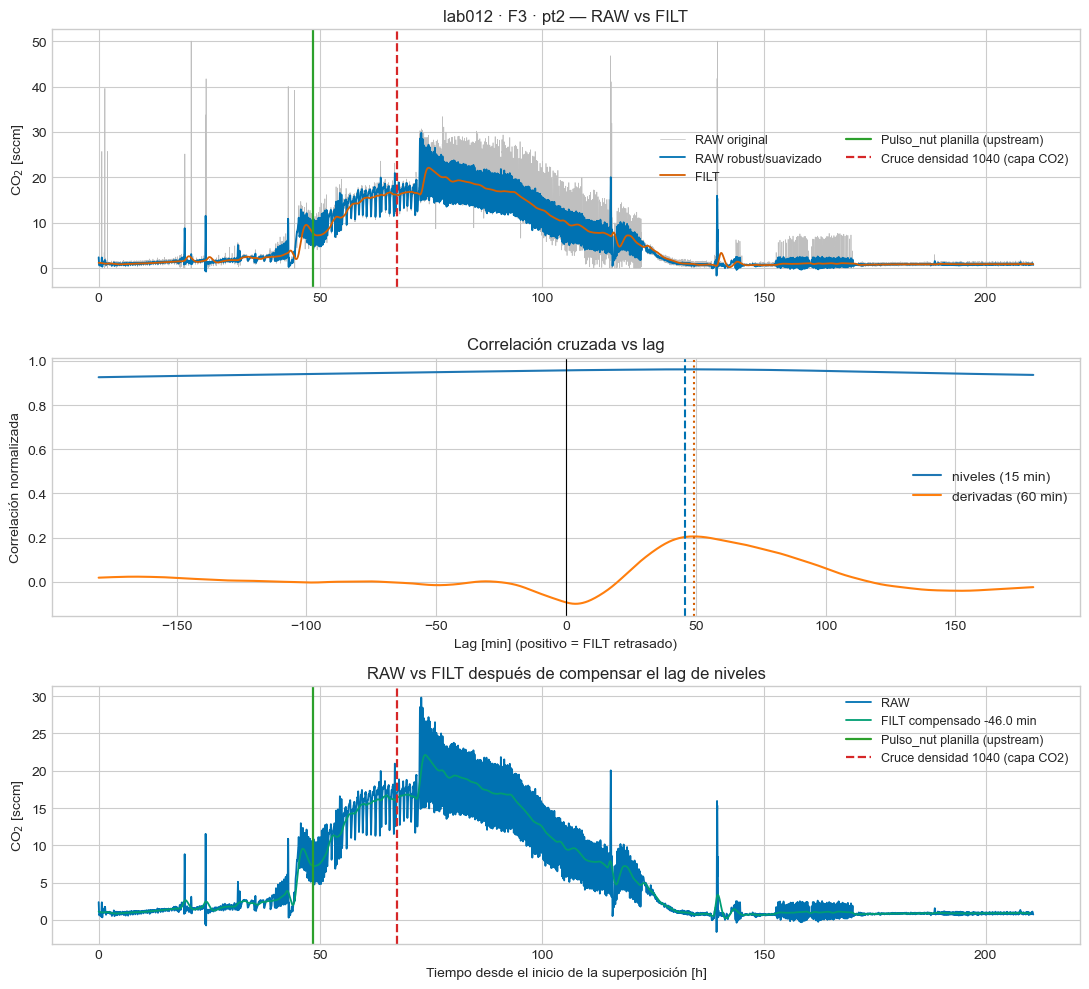

In [11]:
UP_PULSE_STYLE = dict(color="#2ca02c", lw=1.6, ls="-")
CO2P_PULSE_STYLE = dict(color="#d62728", lw=1.6, ls="--")
UP_PULSE_LABEL = "Pulso_nut planilla (upstream)"
CO2P_PULSE_LABEL = "Cruce densidad 1040 (capa CO2)"

def add_nitrogen_pulses(ax, lab_id, t_start):
    """Líneas verticales del pulso 2 según las dos convenciones (LAB004-LAB012)."""
    rows = natural_pulses[natural_pulses["batch"].str.upper().eq(lab_id.upper())]
    if rows.empty:
        return
    row = rows.iloc[0]
    for t_abs, style, label in (
        (row["t_pulse_upstream_abs"], UP_PULSE_STYLE, UP_PULSE_LABEL),
        (row["t_pulse_CO2_abs"], CO2P_PULSE_STYLE, CO2P_PULSE_LABEL),
    ):
        x_h = (t_abs - t_start).total_seconds() / 3600.0
        ax.axvline(x_h, **style, label=label)

for lab_id, result in analysis_cache.items():
    pair = result["pair"]
    prepared = result["prepared"]
    level = result["level"]
    derivative = result["derivative"]
    dt_s = prepared["dt_s"]
    lag = level["lag_samples"]
    t_start = prepared["time"][0]
    time_h = (
        prepared["time"] - t_start
    ).total_seconds().to_numpy() / 3600.0

    compensated = np.full_like(prepared["filt_level"], np.nan, dtype=float)
    if lag > 0:
        compensated[:-lag] = prepared["filt_level"][lag:]
    elif lag < 0:
        compensated[-lag:] = prepared["filt_level"][:lag]
    else:
        compensated[:] = prepared["filt_level"]

    fig, axes = plt.subplots(3, 1, figsize=(11, 10))
    axes[0].plot(time_h, prepared["raw"], color="0.75", lw=0.5, label="RAW original")
    axes[0].plot(time_h, prepared["raw_level"], color="#0072B2", lw=1.3, label="RAW robust/suavizado")
    axes[0].plot(time_h, prepared["filt_level"], color="#D55E00", lw=1.3, label="FILT")
    add_nitrogen_pulses(axes[0], lab_id, t_start)
    axes[0].set_ylabel(r"CO$_2$ [sccm]")
    axes[0].set_title(f"{lab_id} · {pair['fermenter']} · {pair['segment']} — RAW vs FILT")
    axes[0].legend(ncol=2, fontsize=9)

    axes[1].plot(level["lags"] * dt_s / 60.0, level["curve"], label="niveles (15 min)")
    axes[1].plot(
        derivative["lags"] * dt_s / 60.0,
        derivative["curve"],
        label="derivadas (60 min)",
    )
    axes[1].axvline(level["lag_samples"] * dt_s / 60.0, color="#0072B2", ls="--")
    axes[1].axvline(derivative["lag_samples"] * dt_s / 60.0, color="#D55E00", ls=":")
    axes[1].axvline(0, color="black", lw=0.8)
    axes[1].set_xlabel("Lag [min] (positivo = FILT retrasado)")
    axes[1].set_ylabel("Correlación normalizada")
    axes[1].set_title("Correlación cruzada vs lag")
    axes[1].legend()

    axes[2].plot(time_h, prepared["raw_level"], color="#0072B2", lw=1.3, label="RAW")
    axes[2].plot(
        time_h,
        compensated,
        color="#009E73",
        lw=1.3,
        label=f"FILT compensado {-lag * dt_s / 60.0:+.1f} min",
    )
    add_nitrogen_pulses(axes[2], lab_id, t_start)
    axes[2].set_xlabel("Tiempo desde el inicio de la superposición [h]")
    axes[2].set_ylabel(r"CO$_2$ [sccm]")
    axes[2].set_title("RAW vs FILT después de compensar el lag de niveles")
    axes[2].legend(fontsize=9)

    fig.tight_layout()
    fig.savefig(FIGURES / f"{lab_id}_{pair['fermenter']}_{pair['segment']}.png", dpi=150)
    plt.show()
    plt.close(fig)

### 4.2 Comparativa global LAB004–LAB012 — RAW vs FILT sin compensar

La misma vista del primer panel de cada figura anterior, reunida en una sola figura: señal **RAW original**, **RAW robust/suavizado** y **FILT**, **convertidas a g/L/h con la conversión SCCM definitiva de la corrida congelada** (`SCCM_CORRECTED`, factor = 0.0404391928807947 g/L/h por sccm a 2 L, leído de `analysis_manifest.json`), con ambos pulsos de nitrógeno marcados según la nomenclatura de la sección 4.1. La conversión es lineal, por lo que no altera los retardos medidos; solo pone las señales en las unidades de la calibración. El tiempo se mide desde el inicio de la superposición de cada segmento (LAB004–LAB009: campaña de abril; LAB010–LAB012: campaña de mayo).

Conversion SCCM final aplicada: SCCM_CORRECTED = 0.0404391928807947 g/L/h por sccm a 2 L
Fuente: analysis_manifest.json


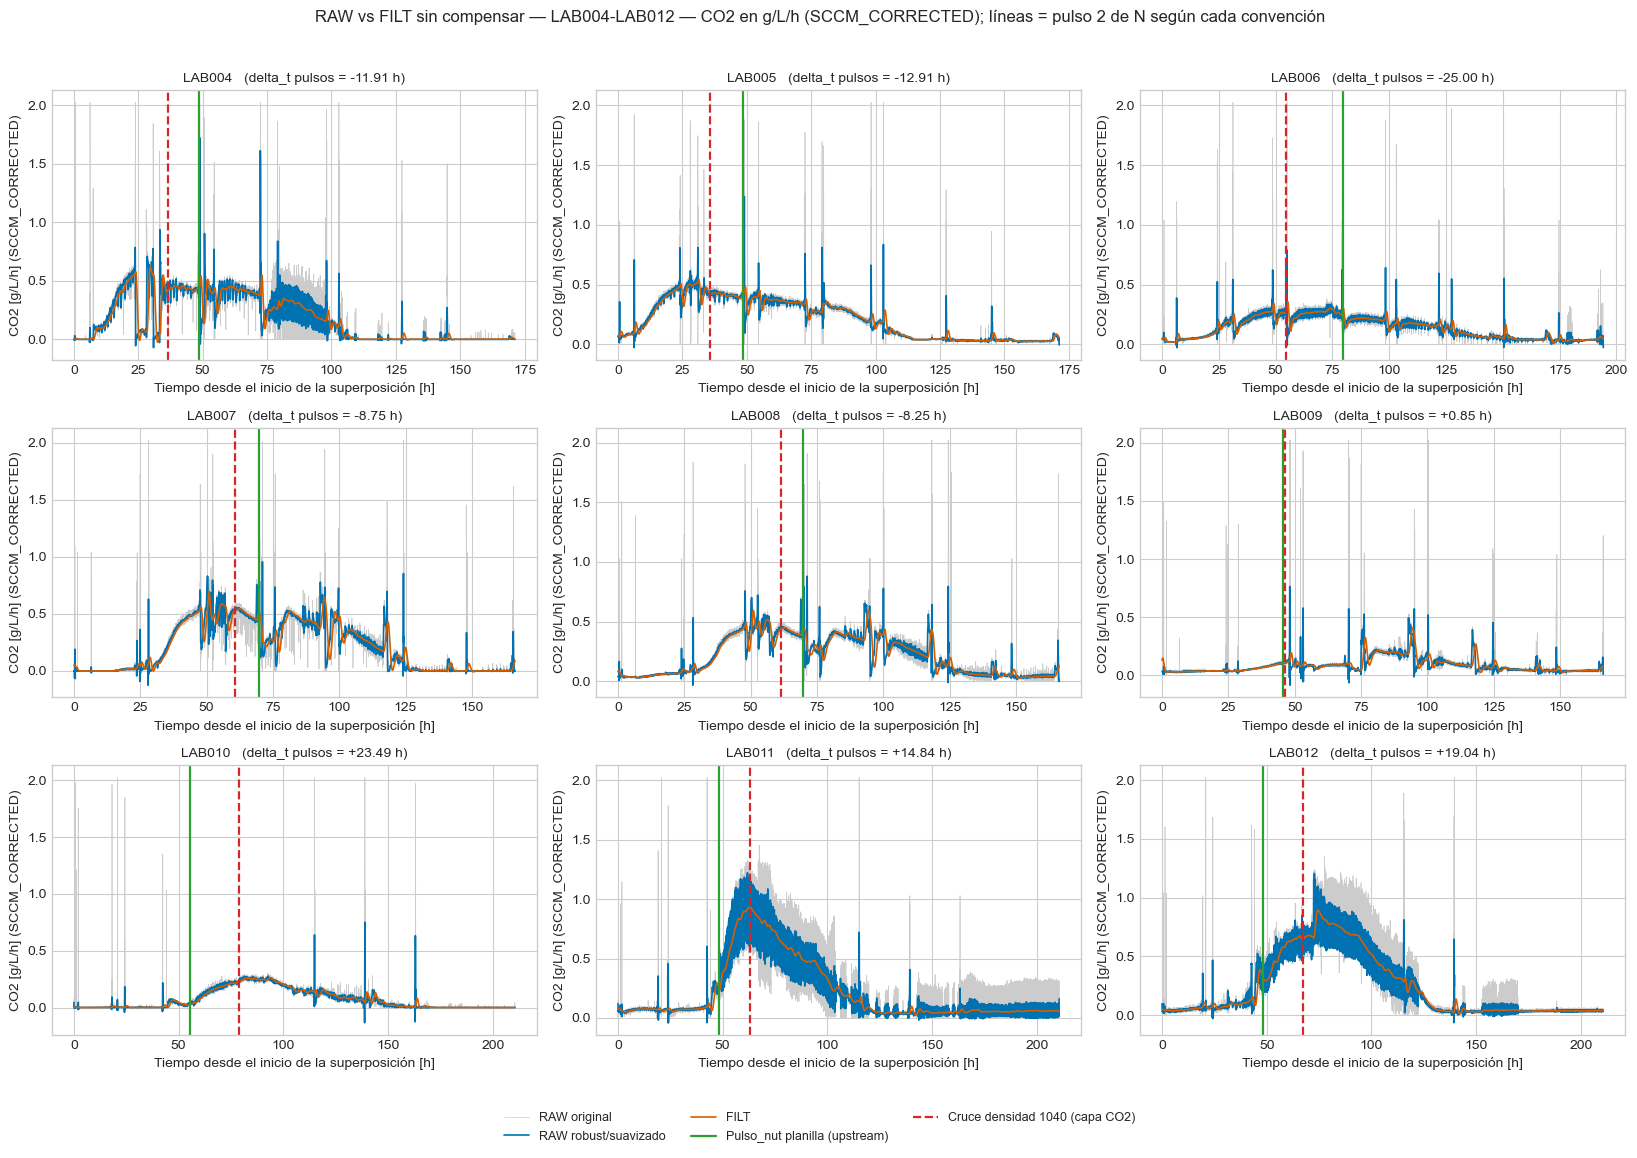

In [12]:
import json as _json

manifest_path = CO2_PULSES.parent / "analysis_manifest.json"
manifest = _json.loads(manifest_path.read_text(encoding="utf-8"))
assert manifest["sccm_conversion"]["name"] == "SCCM_CORRECTED"
sccm_factor = float(manifest["sccm_conversion"]["factor_g_l_h_per_sccm_at_2L"])
print(f"Conversion SCCM final aplicada: SCCM_CORRECTED = {sccm_factor} g/L/h por sccm a 2 L")
print("Fuente:", manifest_path.name)

fig, axes = plt.subplots(3, 3, figsize=(16.5, 11.5))
reference_handles = None
for ax, lab_id in zip(axes.flat, [f"lab{number:03d}" for number in range(4, 13)]):
    prepared = analysis_cache[lab_id]["prepared"]
    t_start = prepared["time"][0]
    time_h = (prepared["time"] - t_start).total_seconds().to_numpy() / 3600.0
    ax.plot(time_h, prepared["raw"] * sccm_factor, color="0.80", lw=0.5, label="RAW original")
    ax.plot(time_h, prepared["raw_level"] * sccm_factor, color="#0072B2", lw=1.2, label="RAW robust/suavizado")
    ax.plot(time_h, prepared["filt_level"] * sccm_factor, color="#D55E00", lw=1.2, label="FILT")
    add_nitrogen_pulses(ax, lab_id, t_start)
    ax.set_xlabel("Tiempo desde el inicio de la superposición [h]")
    ax.set_ylabel("CO2 [g/L/h] (SCCM_CORRECTED)")
    row = natural_pulses[natural_pulses["batch"].str.upper().eq(lab_id.upper())].iloc[0]
    delta = float(row["t_pulse_CO2_h"]) - float(row["t_pulse_upstream_h"])
    ax.set_title(f"{lab_id.upper()}   (delta_t pulsos = {delta:+.2f} h)", fontsize=10)
    if reference_handles is None:
        h1, l1 = ax.get_legend_handles_labels()
        reference_handles = dict(zip(l1, h1))
fig.suptitle(
    "RAW vs FILT sin compensar — LAB004-LAB012 — CO2 en g/L/h (SCCM_CORRECTED); "
    "líneas = pulso 2 de N según cada convención",
    fontsize=12,
)
fig.legend(
    [reference_handles[k] for k in ["RAW original", "RAW robust/suavizado", "FILT", UP_PULSE_LABEL, CO2P_PULSE_LABEL]],
    ["RAW original", "RAW robust/suavizado", "FILT", UP_PULSE_LABEL, CO2P_PULSE_LABEL],
    loc="lower center", bbox_to_anchor=(0.5, -0.015), ncol=3, frameon=False, fontsize=9,
)
fig.tight_layout(rect=(0.0, 0.045, 1.0, 0.965))
plt.show()

### 4.3 Temperaturas de LAB004–LAB012 (mismo estilo que la figura de perfiles del cross-matrix, sin DOE)

**Auditoría del procesamiento de temperatura.** A diferencia del CO2, la señal de temperatura **no lleva filtro Hampel/Butterworth ni corrección de offset**. La cadena completa es:

1. Archivos `Temp_*` (columnas `T`, `SP`, junto a `nutricion_activa`/`freq_nut`).
2. `resample_process_signal(kind="temperature")`: recorte a `[0, horizonte]` del lote y **remuestreo por mediana a 30 min** (único "filtrado": agregación robusta, sin suavizado de fase).
3. `augment_natural_batches_with_temperature`: **interpolación lineal** de ese registro de 30 min sobre la grilla del modelo (grilla propia + instantes de cambio de setpoint), usando el **perfil nominal del protocolo** únicamente antes del primer y después del último punto de sensor.

La figura usa el artefacto canónico del loader (`process_temperature_30min.csv`, lectura only): T medida (mediana 30 min) y setpoint, con ambos pulsos de N marcados según la nomenclatura de la sección 4.1. Aquí el eje es directo: horas desde el origen del lote (misma base de los tiempos de pulso), sin re-basear nada.

Artefacto de temperatura (mediana 30 min, input del modelo): process_temperature_30min.csv
Sin filtro adicional: la temperatura no pasa por Hampel/Butterworth ni correccion de offset.


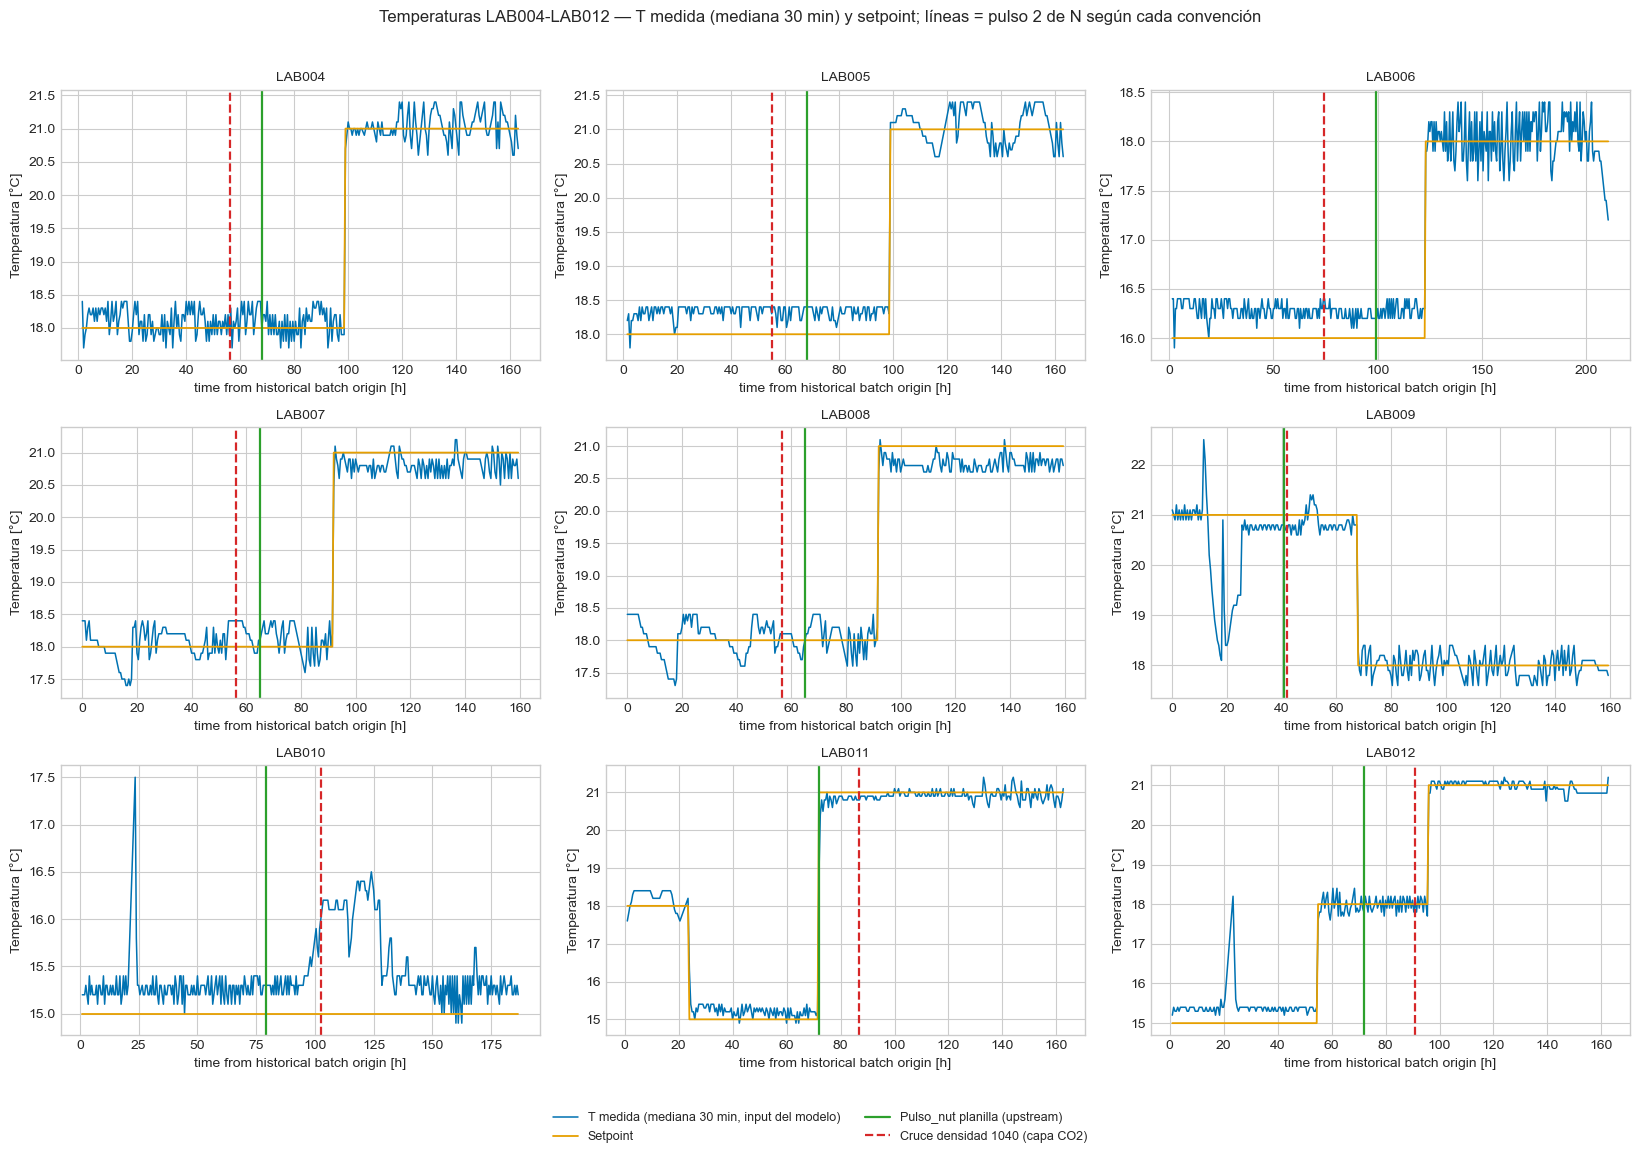

In [13]:
TEMP_PATH = FM_ROOT / "laboratory_2026" / "results" / "estimability_historical_natural" / "process_temperature_30min.csv"
temp30 = pd.read_csv(TEMP_PATH)
temp30["timestamp"] = pd.to_datetime(temp30["timestamp"])
assert sorted(temp30["batch"].unique()) == NATURAL_LABS, "cobertura de temperatura inesperada"
print("Artefacto de temperatura (mediana 30 min, input del modelo):", TEMP_PATH.name)
print("Sin filtro adicional: la temperatura no pasa por Hampel/Butterworth ni correccion de offset.")

fig, axes = plt.subplots(3, 3, figsize=(16.5, 11.5))
reference_handles = None
for ax, lab in zip(axes.flat, NATURAL_LABS):
    g = temp30[temp30["batch"].eq(lab)].sort_values("t_h")
    ax.plot(g["t_h"], g["T"], color="#0072B2", lw=1.1, label="T medida (mediana 30 min, input del modelo)")
    sp = g.dropna(subset=["SP"])
    if not sp.empty:
        ax.plot(sp["t_h"], sp["SP"], color="#E69F00", lw=1.3, label="Setpoint")
    row = natural_pulses[natural_pulses["batch"].eq(lab)].iloc[0]
    ax.axvline(float(row["t_pulse_upstream_h"]), **UP_PULSE_STYLE, label=UP_PULSE_LABEL)
    ax.axvline(float(row["t_pulse_CO2_h"]), **CO2P_PULSE_STYLE, label=CO2P_PULSE_LABEL)
    ax.set_xlabel("time from historical batch origin [h]")
    ax.set_ylabel("Temperatura [°C]")
    ax.set_title(lab, fontsize=10)
    if reference_handles is None:
        h1, l1 = ax.get_legend_handles_labels()
        reference_handles = dict(zip(l1, h1))
fig.suptitle(
    "Temperaturas LAB004-LAB012 — T medida (mediana 30 min) y setpoint; "
    "líneas = pulso 2 de N según cada convención",
    fontsize=12,
)
order = ["T medida (mediana 30 min, input del modelo)", "Setpoint", UP_PULSE_LABEL, CO2P_PULSE_LABEL]
fig.legend(
    [reference_handles[k] for k in order],
    order,
    loc="lower center", bbox_to_anchor=(0.5, -0.015), ncol=2, frameon=False, fontsize=9,
)
fig.tight_layout(rect=(0.0, 0.045, 1.0, 0.965))
plt.show()

## 5. Comparación entre F1, F2 y F3 y estabilidad temporal

Las diferencias por fermentador se interpretan con cautela: F1/F2/F3 están ligados a experimentos distintos y el contenido espectral de cada fermentación afecta el máximo de correlación. El retardo de grupo de un IIR tampoco es estrictamente constante con la frecuencia.


,experiments,level_mean_min,level_median_min,level_std_min,derivative_mean_min,derivative_median_min,derivative_std_min
fermenter,,,,,,,
F1,4,47.288,47.750,4.219,44.742,44.817,3.077
F2,4,42.929,41.792,6.269,45.688,44.458,5.866
F3,4,46.208,44.417,6.214,45.396,45.542,4.608


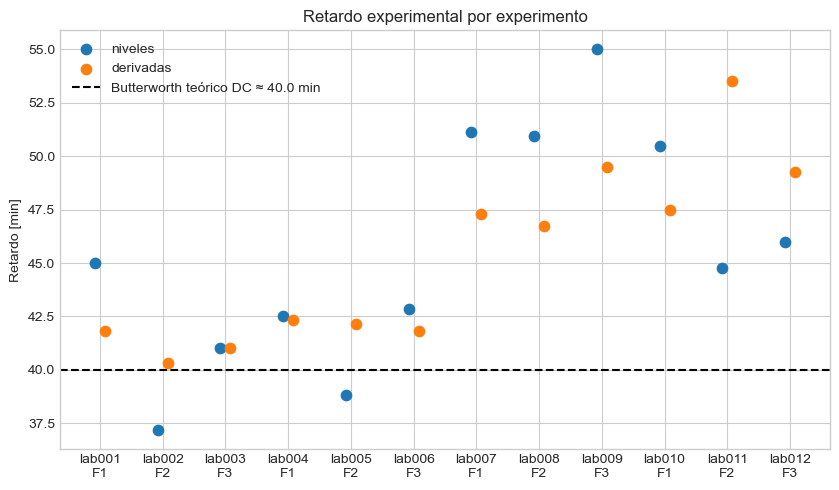

,,windows,window_level_mean_min,window_level_median_min,window_level_std_min,window_level_min,window_level_max
lab_id,fermenter,,,,,,
lab001,F1,4,33.750,40.750,17.605,8.000,45.500
lab002,F2,7,32.667,35.667,11.054,14.833,42.833
lab003,F3,6,28.111,33.667,18.017,0.000,44.000
lab004,F1,11,42.606,43.167,3.436,32.667,45.333
lab005,F2,13,43.256,43.833,2.036,39.667,46.333
lab006,F3,15,43.678,43.167,1.353,41.333,47.000
lab007,F1,11,47.567,50.233,7.649,35.933,57.383
lab008,F2,11,46.900,49.317,7.660,32.267,56.833
lab009,F3,11,50.133,52.067,8.597,34.283,61.233


In [14]:
by_fermenter = delay_summary.groupby("fermenter").agg(
    experiments=("lab_id", "count"),
    level_mean_min=("level_delay_min", "mean"),
    level_median_min=("level_delay_min", "median"),
    level_std_min=("level_delay_min", "std"),
    derivative_mean_min=("derivative_delay_min", "mean"),
    derivative_median_min=("derivative_delay_min", "median"),
    derivative_std_min=("derivative_delay_min", "std"),
)
by_fermenter.to_csv(RESULTS / "delay_by_fermenter.csv")
display(by_fermenter.round(3))

fig, ax = plt.subplots(figsize=(8.5, 5))
x = np.arange(len(delay_summary))
ax.scatter(x - 0.08, delay_summary["level_delay_min"], label="niveles", s=55)
ax.scatter(x + 0.08, delay_summary["derivative_delay_min"], label="derivadas", s=55)
theory_dc = theoretical_delay.loc[
    theoretical_delay["feature_period_h"].eq(np.inf), "group_delay_min"
].median()
ax.axhline(theory_dc, color="black", ls="--", label=f"Butterworth teórico DC ≈ {theory_dc:.1f} min")
ax.set_xticks(x)
ax.set_xticklabels(
    delay_summary["lab_id"] + "\n" + delay_summary["fermenter"], rotation=0
)
ax.set_ylabel("Retardo [min]")
ax.set_title("Retardo experimental por experimento")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES / "delay_comparison_by_experiment.png", dpi=160)
plt.show()
plt.close(fig)

if len(window_summary):
    stable_windows = window_summary[
        (window_summary["level_correlation"] >= 0.35)
        & window_summary["level_lag_min"].between(0, 120)
    ].copy()
    window_by_lab = stable_windows.groupby(["lab_id", "fermenter"]).agg(
        windows=("level_lag_min", "count"),
        window_level_mean_min=("level_lag_min", "mean"),
        window_level_median_min=("level_lag_min", "median"),
        window_level_std_min=("level_lag_min", "std"),
        window_level_min=("level_lag_min", "min"),
        window_level_max=("level_lag_min", "max"),
    )
    display(window_by_lab.round(3))
else:
    stable_windows = pd.DataFrame()
    window_by_lab = pd.DataFrame()
    print("No hubo ventanas con información dinámica suficiente.")


In [15]:
methods = ["level_delay_min", "derivative_delay_min", "t10_delay_min", "t50_delay_min", "t90_delay_min", "peak_delay_min"]
overall = delay_summary[methods].agg(["count", "mean", "median", "std", "min", "max"]).T
overall.index.name = "method"
overall.to_csv(RESULTS / "delay_method_statistics.csv")
display(overall.round(3))

level_mean = delay_summary["level_delay_min"].mean()
level_median = delay_summary["level_delay_min"].median()
derivative_mean = delay_summary["derivative_delay_min"].mean()
derivative_median = delay_summary["derivative_delay_min"].median()
theory_dc = theoretical_delay.loc[
    theoretical_delay["feature_period_h"].eq(np.inf), "group_delay_min"
].median()

if len(stable_windows):
    window_median = stable_windows["level_lag_min"].median()
    within_iqr = stable_windows["level_lag_min"].quantile(0.75) - stable_windows["level_lag_min"].quantile(0.25)
    window_text = (
        f"{len(stable_windows)} ventanas válidas; mediana {window_median:.1f} min "
        f"e IQR {within_iqr:.1f} min"
    )
else:
    window_text = "sin ventanas válidas suficientes"

print("RESUMEN REPRODUCIBLE")
print(f"- CSV físicos: {len(inventory)} (RAW={(inventory.role == 'RAW').sum()}, FILT={(inventory.role == 'FILT').sum()})")
print(
    f"- Contenidos únicos: RAW={((inventory.role == 'RAW') & inventory.canonical_file).sum()}, "
    f"FILT={((inventory.role == 'FILT') & inventory.canonical_file).sum()}"
)
print(f"- Pares de segmento completos: {int(pairs.complete.sum())}")
print(f"- Experimentos seleccionados: {int(pairs.selected.sum())}")
print(f"- Períodos observados: {observed_periods} s")
print(f"- Correlación de niveles: media={level_mean:.2f} min, mediana={level_median:.2f} min")
print(f"- Correlación de derivadas: media={derivative_mean:.2f} min, mediana={derivative_median:.2f} min")
print(f"- Butterworth teórico, límite de baja frecuencia: {theory_dc:.2f} min")
print(f"- Ventanas: {window_text}")
print(f"- Resultados escritos en: {RESULTS}")


,count,mean,median,std,min,max
method,,,,,,
level_delay_min,12.0,45.475,44.875,5.464,37.167,55.00
derivative_delay_min,12.0,45.275,44.542,4.234,40.333,53.50
t10_delay_min,5.0,28.950,17.833,31.531,0.000,68.00
t50_delay_min,1.0,102.000,102.000,NaN,102.000,102.00
t90_delay_min,0.0,NaN,NaN,NaN,NaN,NaN
peak_delay_min,6.0,47.917,42.750,27.357,24.167,98.25


RESUMEN REPRODUCIBLE
- CSV físicos: 65 (RAW=34, FILT=31)
- Contenidos únicos: RAW=27, FILT=24
- Pares de segmento completos: 24
- Experimentos seleccionados: 12
- Períodos observados: [10.0, 11.0, 15.0] s
- Correlación de niveles: media=45.48 min, mediana=44.88 min
- Correlación de derivadas: media=45.27 min, mediana=44.54 min
- Butterworth teórico, límite de baja frecuencia: 40.00 min
- Ventanas: 116 ventanas válidas; mediana 44.2 min e IQR 9.8 min
- Resultados escritos en: D:\claud\Desktop\Universidad\Memoria\Model\pyomo-doe\fermentation_model\laboratory_2026\results\co2_filter_delay_analysis


## Interpretación

- Los archivos FILT representan la salida de la cadena completa Hampel + Butterworth; por tanto, el valor experimental se denomina **retardo efectivo de la cadena de filtrado**.
- Hampel es causal, pero deja pasar las observaciones no clasificadas como spikes. Su contribución sistemática al retardo es menor que la del Butterworth; modifica localmente la señal cuando reemplaza una observación por la mediana de su ventana pasada.
- El Butterworth causal de tercer orden tiene fase no lineal. Un dead-time fijo puede ser una aproximación operacional útil para las variaciones lentas de fermentación si las estimaciones por niveles, derivadas y ventanas son concordantes, pero no reproduce exactamente todas las frecuencias ni los transitorios.
- Las diferencias entre fermentadores no deben atribuirse automáticamente al hardware: también cambian el experimento, amplitud, temperatura y contenido espectral de la señal.


## Relación entre dinámica térmica y fluctuaciones de CO₂

Esta sección reutiliza el inventario, los pares seleccionados, los parámetros Hampel y las funciones de correlación anteriores. No recalcula ni redefine el análisis de retardo.

Los registros térmicos contienen directamente `T`, `SP`, `banda`, `hot` y `cold`; las acciones del controlador no se infieren. La salida después de Hampel se reconstruye con el algoritmo causal y sus parámetros documentados.

Se define reproduciblemente:

**CO₂ rápido = CO₂ después de Hampel − tendencia Savitzky–Golay centrada de 120 min.**

Esto conserva variaciones menores que aproximadamente dos horas, elimina primero los spikes conocidos de muestreo y no confunde `RAW − FILT` con alta frecuencia. En las correlaciones cruzadas, **lag > 0 significa que CO₂ cambia después de la variable térmica**.

Para `LAB005_PT2` se conserva y sincroniza el registro completo, pero todas las métricas térmicas representativas (tendencia, componentes rápidas, correlaciones, eventos, PSD y coherencia) se calculan deliberadamente en la ventana fija **t = 20–60 h**, donde `t = 0` es el primer timestamp del archivo CO₂ RAW del experimento. La selección se hace por tiempo transcurrido y no depende de chunks ni de una búsqueda automática de actividad.


In [16]:
from collections import deque

THERMAL_REQUIRED = {"timestamp", "fermentador", "T", "SP", "banda", "cold", "hot"}

def classify_temperature_file(path: Path) -> dict:
    low = path.name.lower()
    lm = re.search(r"lab0*(\d+)", low)
    number = int(lm.group(1)) if lm else None
    lab_id = f"lab{number:03d}" if number is not None else None
    fm = re.search(r"(?:^|_)f([123])(?:_|\.|$)", low)
    fermenter = f"F{fm.group(1)}" if fm else (f"F{((number - 1) % 3) + 1}" if number else None)
    pm = re.search(r"pt\.?\s*(\d+)", low)
    segment = f"pt{int(pm.group(1))}" if pm else ("initial" if "ing26" in low else "main")
    return {"lab_id": lab_id, "lab_number": number, "fermenter": fermenter, "segment": segment}

def inspect_temperature_csv(path: Path) -> dict:
    header = pd.read_csv(path, nrows=0).columns.tolist()
    if not THERMAL_REQUIRED.issubset(header):
        return {}
    frame = pd.read_csv(path, usecols=list(THERMAL_REQUIRED))
    timestamp = pd.to_datetime(frame["timestamp"], errors="coerce")
    differences = timestamp.sort_values().diff().dt.total_seconds().dropna()
    positive = differences[differences > 0]
    sample_s = float(positive.median()) if len(positive) else np.nan
    return {
        **classify_temperature_file(path),
        "relative_path": str(path.relative_to(RAW_ROOT)),
        "rows": len(frame), "columns": "|".join(header),
        "start": timestamp.min(), "end": timestamp.max(),
        "duration_h": (timestamp.max() - timestamp.min()).total_seconds() / 3600,
        "sample_s_median": sample_s,
        "invalid_timestamps": int(timestamp.isna().sum()),
        "duplicate_timestamps": int(timestamp.duplicated().sum()),
        "meaningful_gaps": int((differences > max(60, 5 * sample_s)).sum()),
        "hot_fraction": float(pd.to_numeric(frame["hot"], errors="coerce").fillna(0).mean()),
        "cold_fraction": float(pd.to_numeric(frame["cold"], errors="coerce").fillna(0).mean()),
        "sha256": hashlib.sha256(path.read_bytes()).hexdigest(),
    }

thermal_rows = []
for path in sorted((p for p in RAW_ROOT.rglob("*.csv") if "co2" not in p.name.lower()), key=lambda p: str(p).lower()):
    record = inspect_temperature_csv(path)
    if record:
        thermal_rows.append(record)

temperature_inventory = pd.DataFrame(thermal_rows)
temperature_inventory["path_depth"] = temperature_inventory["relative_path"].map(lambda p: len(Path(p).parts))
temperature_inventory = temperature_inventory.sort_values(["sha256", "path_depth", "relative_path"]).reset_index(drop=True)
temperature_inventory["canonical_file"] = ~temperature_inventory.duplicated("sha256", keep="first")
temperature_inventory["duplicate_copy"] = ~temperature_inventory["canonical_file"]
temperature_inventory.to_csv(RESULTS / "temperature_file_inventory.csv", index=False)
temperature_unique = temperature_inventory[temperature_inventory["canonical_file"]].copy()

thermal_pair_rows = []
for pair_index, pair in pairs[pairs["selected"]].iterrows():
    candidates = temperature_unique[
        (temperature_unique["lab_id"] == pair["lab_id"])
        & (temperature_unique["fermenter"] == pair["fermenter"])
    ].copy()
    co2_start = max(pair["raw_start"], pair["filt_start"])
    co2_end = min(pair["raw_end"], pair["filt_end"])
    candidates["overlap_h"] = candidates.apply(
        lambda r: max(0, (min(co2_end, r["end"]) - max(co2_start, r["start"])).total_seconds() / 3600),
        axis=1,
    )
    best = candidates.sort_values(["overlap_h", "duration_h"], ascending=False).iloc[0]
    thermal_pair_rows.append({
        "pair_index": pair_index, "lab_id": pair["lab_id"], "fermenter": pair["fermenter"],
        "co2_segment": pair["segment"], "raw_file": pair["raw_file"], "filt_file": pair["filt_file"],
        "temperature_file": best["relative_path"], "temperature_segment": best["segment"],
        "overlap_h": best["overlap_h"], "co2_sample_s": pair_cache[pair_index]["dt_s"],
        "temperature_sample_s": best["sample_s_median"], "temperature_gaps": best["meaningful_gaps"],
    })

thermal_pairs = pd.DataFrame(thermal_pair_rows).sort_values("lab_id").reset_index(drop=True)
thermal_pairs.to_csv(RESULTS / "co2_temperature_pairs.csv", index=False)
print(f"Archivos térmicos físicos={len(temperature_inventory)}, únicos={len(temperature_unique)}, copias={temperature_inventory['duplicate_copy'].sum()}")
print("Períodos térmicos [s]:", sorted(temperature_unique["sample_s_median"].dropna().unique()))
display(thermal_pairs)

# Los análisis de retardo ya terminaron y el bloque térmico solo necesita thermal_pairs.
# Liberar estos arrays evita retener simultáneamente dos juegos completos de señales.
pair_cache.clear()
analysis_cache.clear()


Archivos térmicos físicos=39, únicos=30, copias=9
Períodos térmicos [s]: [3.0, 4.0, 5.0]


,pair_index,lab_id,fermenter,co2_segment,raw_file,filt_file,temperature_file,temperature_segment,overlap_h,co2_sample_s,temperature_sample_s,temperature_gaps
0,0,lab001,F1,28_03_26_1700,CO2_lab001_28_03_26_1700.csv,CO2_FILT_lab001_28_03_26_1700.csv,ing26_lab001.csv,initial,26.152778,10.0,3.0,0
1,5,lab002,F2,pt3,CO2_F2_lab002_pt3.csv,CO2_FILT_F2_lab002_pt3.csv,Temp_F2_lab002_pt3.csv,pt3,44.958333,10.0,3.0,0
2,8,lab003,F3,pt3,Desktop_CyT_Tablero_Proceso\CO2_F3_lab003_pt3.csv,Desktop_CyT_Tablero_Proceso\CO2_FILT_F3_lab003...,Temp_F3_lab003_pt3.csv,pt3,44.952778,10.0,3.0,0
3,10,lab004,F1,pt2,CO2_F1_LAB004_PT2.csv,CO2_FILT_F1_LAB004_PT2.csv,Temp_F1_lab004_PT2.csv,pt2,171.268333,10.0,3.0,0
4,12,lab005,F2,pt2,CO2_F2_LAB005_PT2.csv,CO2_FILT_F2_LAB005_PT2.csv,Temp_F2_LAB005_PT2.csv,pt2,171.274444,10.0,3.0,0
5,14,lab006,F3,pt2,CO2_F3_LAB006_PT2.csv,CO2_FILT_F3_LAB006_PT2.csv,Temp_F3_LAB006_PT2.csv,pt2,194.255278,10.0,3.0,0
6,15,lab007,F1,main,CO2_F1_lab007.csv,CO2_FILT_F1_lab007.csv,Temp_F1_lab007.csv,main,166.274722,11.0,4.0,0
7,16,lab008,F2,main,CO2_F2_lab008.csv,CO2_FILT_F2_lab008.csv,Temp_F2_lab008.csv,main,166.270278,11.0,4.0,0
8,17,lab009,F3,main,CO2_F3_lab009.csv,CO2_FILT_F3_lab009.csv,Temp_F3_lab009.csv,main,166.262778,11.0,4.0,0
9,19,lab010,F1,pt2,CO2_F1_lab10_PT2.csv,CO2_FILT_F1_lab10_PT2.csv,Temp_F1_lab10_PT2.csv,pt2,210.667500,15.0,5.0,1


In [17]:
def reconstruct_hampel(values: np.ndarray, window_samples: int):
    buffer = deque(maxlen=max(1, int(window_samples)))
    output = np.empty(len(values), dtype=float)
    spikes = np.zeros(len(values), dtype=bool)
    for i, value in enumerate(np.asarray(values, dtype=float)):
        buffer.append(float(value))
        if len(buffer) < 3:
            output[i] = value
            continue
        array = np.asarray(buffer)
        median = float(np.median(array))
        mad = float(np.median(np.abs(array - median)))
        threshold = max(HAMPEL_K * 1.4826 * mad, MIN_ABS_SPIKE)
        spikes[i] = abs(value - median) > threshold
        output[i] = median if spikes[i] else value
    return output, spikes

def load_temperature(relative_path: str) -> pd.DataFrame:
    columns = ["timestamp", "fermentador", "T", "SP", "banda", "cold", "hot"]
    frame = pd.read_csv(RAW_ROOT / relative_path, usecols=columns)
    frame["timestamp"] = pd.to_datetime(frame["timestamp"], errors="coerce")
    for name in ["T", "SP", "banda", "cold", "hot"]:
        frame[name] = pd.to_numeric(frame[name], errors="coerce")
    return frame.dropna(subset=["timestamp", "T"]).sort_values("timestamp").drop_duplicates("timestamp")

def state_from_columns(hot, cold):
    hot, cold = int(round(float(hot))), int(round(float(cold)))
    if hot and not cold: return "HOT"
    if cold and not hot: return "COLD"
    if not hot and not cold: return "OFF"
    return "CONFLICT"

def longest_complete_block(frame: pd.DataFrame, required: list[str]):
    valid = frame[required].notna().all(axis=1)
    groups = valid.ne(valid.shift(fill_value=False)).cumsum()
    sizes = frame.loc[valid].groupby(groups[valid]).size()
    return frame.loc[valid & groups.eq(sizes.idxmax())].reset_index(drop=True) if len(sizes) else frame.iloc[:0].copy()

def safe_savgol(values, window_seconds, dt_s, order=2):
    window = odd_window(window_seconds, dt_s, len(values), minimum=5)
    return signal.savgol_filter(np.asarray(values, float), window, order) if window > order else np.asarray(values, float)

def refractory_events(frame: pd.DataFrame, seconds=60):
    kept, last = [], None
    for index, timestamp in zip(frame.index, frame["timestamp"]):
        if last is None or (timestamp - last).total_seconds() >= seconds:
            kept.append(index)
            last = timestamp
    return frame.loc[kept].copy()

def prepare_thermal_experiment(mapping: pd.Series):
    raw = read_signal(mapping["raw_file"], "RAW")
    filt = pd.read_csv(RAW_ROOT / mapping["filt_file"], usecols=["timestamp", "flow_filt_sccm", "is_spike"])
    filt["timestamp"] = pd.to_datetime(filt["timestamp"], errors="coerce")
    filt["flow_filt_sccm"] = pd.to_numeric(filt["flow_filt_sccm"], errors="coerce")
    filt["is_spike"] = pd.to_numeric(filt["is_spike"], errors="coerce").fillna(0).astype(int)
    filt = filt.dropna(subset=["timestamp", "flow_filt_sccm"]).sort_values("timestamp").drop_duplicates("timestamp")
    thermal = load_temperature(mapping["temperature_file"])

    raw_dt = float(raw["timestamp"].diff().dt.total_seconds().dropna().median())
    # El código usa período nominal de 10 s. La ventana de 12 muestras reproduce
    # los flags is_spike (F1 >= 0.997) incluso cuando el timestamp real mediano es 15 s.
    nominal_dt = 10.0
    hampel_window = int(round(W_SPIKE_SECONDS / nominal_dt))
    hampel, reconstructed_spike = reconstruct_hampel(raw["value"].to_numpy(), hampel_window)
    raw = raw.assign(co2_hampel=hampel, reconstructed_spike=reconstructed_spike.astype(int))

    flag_match = pd.merge_asof(
        filt[["timestamp", "is_spike"]], raw[["timestamp", "reconstructed_spike"]],
        on="timestamp", direction="nearest",
        tolerance=pd.Timedelta(seconds=max(2, raw_dt / 2)),
    ).dropna(subset=["reconstructed_spike"])
    if len(flag_match):
        observed = flag_match["is_spike"].astype(bool).to_numpy()
        reconstructed = flag_match["reconstructed_spike"].astype(bool).to_numpy()
        tp, fp, fn = np.sum(observed & reconstructed), np.sum(~observed & reconstructed), np.sum(observed & ~reconstructed)
        flag_f1 = float(2 * tp / (2 * tp + fp + fn)) if (2 * tp + fp + fn) else np.nan
    else:
        flag_f1 = np.nan

    start = max(raw["timestamp"].min(), filt["timestamp"].min(), thermal["timestamp"].min())
    end = min(raw["timestamp"].max(), filt["timestamp"].max(), thermal["timestamp"].max())
    dt_s = float(max(1, round(raw_dt)))
    frequency = f"{int(dt_s)}s"
    grid = pd.date_range(start.ceil(frequency), end.floor(frequency), freq=frequency)

    raw_bins = raw.set_index("timestamp")[["value", "co2_hampel", "reconstructed_spike"]].resample(frequency, origin="epoch").agg(
        {"value": "median", "co2_hampel": "median", "reconstructed_spike": "max"}
    )
    filt_bins = filt.set_index("timestamp")[["flow_filt_sccm", "is_spike"]].resample(frequency, origin="epoch").agg(
        {"flow_filt_sccm": "median", "is_spike": "max"}
    )
    temp_bins = thermal.set_index("timestamp")[["T", "SP", "banda", "hot", "cold"]].resample(frequency, origin="epoch").agg(
        {"T": "median", "SP": "median", "banda": "median", "hot": "last", "cold": "last"}
    )
    aligned = pd.DataFrame(index=grid)
    aligned = aligned.join(raw_bins.rename(columns={"value": "co2_raw"}))
    aligned = aligned.join(filt_bins.rename(columns={"flow_filt_sccm": "co2_filt", "is_spike": "observed_spike"}))
    aligned = aligned.join(temp_bins)
    continuous = ["co2_raw", "co2_hampel", "co2_filt", "T", "SP", "banda"]
    original_raw_coverage = float(aligned["co2_raw"].notna().mean())
    original_temp_coverage = float(aligned["T"].notna().mean())
    aligned[continuous] = aligned[continuous].interpolate(limit=2, limit_area="inside")
    aligned[["hot", "cold"]] = aligned[["hot", "cold"]].ffill(limit=2)
    aligned = aligned.reset_index(names="timestamp")
    full_block = longest_complete_block(aligned, ["co2_hampel", "co2_filt", "T", "SP", "hot", "cold"])
    if len(full_block) < 100:
        raise ValueError(f"Bloque insuficiente: {mapping['lab_id']}")

    experiment_start = raw["timestamp"].min()
    requested_start, requested_end = full_block["timestamp"].iloc[[0, -1]]
    if mapping["lab_id"] == "lab005":
        requested_start = experiment_start + pd.Timedelta(hours=20)
        requested_end = experiment_start + pd.Timedelta(hours=60)
        if requested_start < full_block["timestamp"].iloc[0] or requested_end > full_block["timestamp"].iloc[-1]:
            raise ValueError("LAB005_PT2 no cubre completamente la ventana térmica solicitada de 20–60 h")
        block = full_block[full_block["timestamp"].between(requested_start, requested_end)].copy()
    else:
        block = full_block
    if len(block) < 100:
        raise ValueError(f"Ventana térmica insuficiente: {mapping['lab_id']}")

    block["co2_trend"] = safe_savgol(block["co2_hampel"], 120 * 60, dt_s)
    block["co2_fast"] = block["co2_hampel"] - block["co2_trend"]
    block["filt_trend"] = safe_savgol(block["co2_filt"], 120 * 60, dt_s)
    block["filt_fast"] = block["co2_filt"] - block["filt_trend"]
    block["temp_error"] = block["T"] - block["SP"]
    block["temp_fast"] = block["temp_error"] - safe_savgol(block["temp_error"], 120 * 60, dt_s)
    block["dtemp_dt_c_min"] = np.gradient(safe_savgol(block["T"], 2 * 60, dt_s), dt_s) * 60
    block["dco2_dt_sccm_min"] = np.gradient(safe_savgol(block["co2_fast"], 2 * 60, dt_s), dt_s) * 60
    block["state"] = [state_from_columns(h, c) for h, c in zip(block["hot"], block["cold"])]

    nearest = pd.merge_asof(
        raw[["timestamp"]], thermal[["timestamp"]].rename(columns={"timestamp": "thermal_timestamp"}),
        left_on="timestamp", right_on="thermal_timestamp", direction="nearest", tolerance=pd.Timedelta(seconds=30),
    ).dropna()
    clock_offset = float((nearest["timestamp"] - nearest["thermal_timestamp"]).abs().dt.total_seconds().median()) if len(nearest) else np.nan

    events = thermal[thermal["timestamp"].between(block["timestamp"].min(), block["timestamp"].max())].copy()
    events["state"] = [state_from_columns(h, c) for h, c in zip(events["hot"], events["cold"])]
    events["previous_state"] = events["state"].shift()
    events = events[
        events["state"].ne(events["previous_state"])
        & events["state"].isin(["OFF", "HOT", "COLD"])
        & events["previous_state"].isin(["OFF", "HOT", "COLD"])
    ].copy()
    events["transition"] = events["previous_state"] + "->" + events["state"]
    events = refractory_events(events, 60)
    if mapping["lab_id"] == "lab005":
        print(
            "LAB005_PT2 — ventana térmica fija:",
            f"solicitada {requested_start} a {requested_end};",
            f"grilla efectiva {block['timestamp'].iloc[0]} a {block['timestamp'].iloc[-1]};",
            f"muestras={len(block)}, duración={(block['timestamp'].iloc[-1] - block['timestamp'].iloc[0]).total_seconds() / 3600:.4f} h;",
            f"entradas HOT={events['state'].eq('HOT').sum()}, entradas COLD={events['state'].eq('COLD').sum()}",
        )

    return {
        "block": block, "events": events, "dt_s": dt_s, "hampel_window_samples": hampel_window,
        "experiment_start": experiment_start,
        "requested_window_start": requested_start, "requested_window_end": requested_end,
        "analysis_window_start": block["timestamp"].iloc[0], "analysis_window_end": block["timestamp"].iloc[-1],
        "analysis_window_start_h": (block["timestamp"].iloc[0] - experiment_start).total_seconds() / 3600,
        "analysis_window_end_h": (block["timestamp"].iloc[-1] - experiment_start).total_seconds() / 3600,
        "full_synchronized_h": (full_block["timestamp"].iloc[-1] - full_block["timestamp"].iloc[0]).total_seconds() / 3600,
        "nominal_filter_sample_s": nominal_dt,
        "hampel_flag_f1": flag_f1, "reconstructed_spikes": int(raw["reconstructed_spike"].sum()),
        "observed_spikes": int(filt["is_spike"].sum()), "clock_offset_s": clock_offset,
        "raw_coverage": original_raw_coverage, "temp_coverage": original_temp_coverage,
    }

EVENT_RELATIVE_MIN = np.arange(-30, 31, dtype=float)

def sample_event_profile(block, event_time):
    base = block["timestamp"].astype("int64").to_numpy()
    target = event_time.value + (EVENT_RELATIVE_MIN * 60e9).astype(np.int64)
    positions = np.clip(np.searchsorted(base, target), 1, len(base) - 1)
    left = positions - 1
    nearest = np.where(np.abs(base[left] - target) <= np.abs(base[positions] - target), left, positions)
    valid = np.abs(base[nearest] - target) <= 2 * (base[1] - base[0])
    if valid.mean() < 0.9:
        return None
    columns = ["T", "dtemp_dt_c_min", "co2_hampel", "co2_fast", "dco2_dt_sccm_min", "filt_fast"]
    profile = block.iloc[nearest][columns].reset_index(drop=True)
    profile.insert(0, "relative_min", EVENT_RELATIVE_MIN)
    profile.loc[~valid, columns] = np.nan
    return profile

def strongest_cross_correlation(x, y, max_lag_samples):
    result = cross_correlation(x, y, max_lag_samples)
    best = int(np.argmax(np.abs(result["curve"])))
    result["lag_samples"] = int(result["lags"][best])
    result["correlation"] = float(result["curve"][best])
    return result

def clustered_event_stats(effects, destination, start_time, seed):
    subset = effects[effects["to_state"].eq(destination)].copy()
    if subset.empty:
        return np.nan, (np.nan, np.nan), np.nan, 0
    subset["block_6h"] = ((subset["timestamp"] - start_time).dt.total_seconds() // (6 * 3600)).astype(int)
    block_medians = subset.groupby("block_6h")["co2_fast_effect_sccm"].median().to_numpy()
    median = float(subset["co2_fast_effect_sccm"].median())
    consistency = float(np.mean(np.sign(block_medians) == np.sign(median))) if median != 0 else np.nan
    if len(block_medians) < 5:
        return median, (np.nan, np.nan), consistency, len(block_medians)
    rng = np.random.default_rng(seed)
    boot = np.median(rng.choice(block_medians, (2000, len(block_medians)), replace=True), axis=1)
    return median, tuple(np.quantile(boot, [0.025, 0.975])), consistency, len(block_medians)

def event_peak_metrics(profiles, destination):
    if profiles.empty:
        return np.nan, np.nan
    subset = profiles[profiles["transition"].str.endswith("->" + destination)]
    if subset.empty:
        return np.nan, np.nan
    curve = subset.groupby("relative_min")["co2_fast_response"].mean()
    after = curve.loc[(curve.index >= 0) & (curve.index <= 30)]
    if after.empty:
        return np.nan, np.nan
    peak_lag = float(after.idxmax() if destination == "HOT" else after.idxmin())
    return float(after.loc[peak_lag]), peak_lag

def spectral_metrics(block, dt_s):
    fs, n = 1 / dt_s, len(block)
    target = min(n, max(256, int(round(12 * 3600 / dt_s))))
    nperseg = 2 ** int(np.floor(np.log2(target)))
    x = signal.detrend(block["temp_fast"].to_numpy())
    y = signal.detrend(block["co2_fast"].to_numpy())
    yf = signal.detrend(block["filt_fast"].to_numpy())
    frequency, p_temp = signal.welch(x, fs=fs, nperseg=nperseg, noverlap=nperseg // 2)
    _, p_co2 = signal.welch(y, fs=fs, nperseg=nperseg, noverlap=nperseg // 2)
    _, p_filt = signal.welch(yf, fs=fs, nperseg=nperseg, noverlap=nperseg // 2)
    _, coherence = signal.coherence(x, y, fs=fs, nperseg=nperseg, noverlap=nperseg // 2)
    periods = np.divide(1, frequency * 60, out=np.full_like(frequency, np.inf), where=frequency > 0)
    band = (periods >= 2) & (periods <= 120)
    indices = np.flatnonzero(band)
    ti = indices[np.argmax(p_temp[band])]
    ci = indices[np.argmax(p_co2[band])]
    ki = indices[np.argmax(coherence[band])]
    return {
        "frequency_hz": frequency, "periods_min": periods, "temp_psd": p_temp, "co2_psd": p_co2, "filt_psd": p_filt,
        "coherence": coherence, "dominant_temp_period_min": float(periods[ti]),
        "dominant_temp_frequency_hz": float(frequency[ti]),
        "dominant_co2_period_min": float(periods[ci]), "dominant_co2_frequency_hz": float(frequency[ci]),
        "coherence_at_temp_peak": float(coherence[ti]),
        "max_coherence": float(coherence[ki]), "max_coherence_period_min": float(periods[ki]),
        "max_coherence_frequency_hz": float(frequency[ki]),
        "filter_gain_at_temp_peak": float(np.sqrt(max(p_filt[ti], 0) / max(p_co2[ti], 1e-30))),
    }


In [18]:
def analyze_thermal_experiment(mapping):
    prepared = prepare_thermal_experiment(mapping)
    block, dt_s = prepared["block"], prepared["dt_s"]
    max_lag = int(round(60 * 60 / dt_s))
    temp_cross = strongest_cross_correlation(block["temp_fast"], block["co2_fast"], max_lag)
    derivative_cross = strongest_cross_correlation(block["dtemp_dt_c_min"], block["dco2_dt_sccm_min"], max_lag)

    effect_rows, profile_frames = [], []
    for _, event in prepared["events"].iterrows():
        profile = sample_event_profile(block, event["timestamp"])
        if profile is None:
            continue
        before = profile[profile["relative_min"].between(-10, -1)]
        after = profile[profile["relative_min"].between(1, 10)]
        if len(before) < 8 or len(after) < 8:
            continue
        effect_rows.append({
            "lab_id": mapping["lab_id"], "fermenter": mapping["fermenter"],
            "timestamp": event["timestamp"], "transition": event["transition"],
            "from_state": event["previous_state"], "to_state": event["state"],
            "co2_fast_effect_sccm": float(after["co2_fast"].mean() - before["co2_fast"].mean()),
            "filt_fast_effect_sccm": float(after["filt_fast"].mean() - before["filt_fast"].mean()),
            "co2_rms_before": float(np.sqrt(np.mean(before["co2_fast"] ** 2))),
            "co2_rms_after": float(np.sqrt(np.mean(after["co2_fast"] ** 2))),
        })
        profile["co2_fast_response"] = profile["co2_fast"] - before["co2_fast"].mean()
        profile["filt_fast_response"] = profile["filt_fast"] - before["filt_fast"].mean()
        profile_frames.append(profile.assign(
            lab_id=mapping["lab_id"], fermenter=mapping["fermenter"],
            transition=event["transition"], event_timestamp=event["timestamp"],
        ))

    effects = pd.DataFrame(effect_rows)
    profiles = pd.concat(profile_frames, ignore_index=True) if profile_frames else pd.DataFrame()
    hot_peak_effect, hot_peak_lag = event_peak_metrics(profiles, "HOT")
    cold_peak_effect, cold_peak_lag = event_peak_metrics(profiles, "COLD")
    hot_median, hot_ci, hot_consistency, hot_blocks = clustered_event_stats(
        effects, "HOT", block["timestamp"].iloc[0], 2026 + int(mapping["lab_id"][-3:])
    )
    cold_median, cold_ci, cold_consistency, cold_blocks = clustered_event_stats(
        effects, "COLD", block["timestamp"].iloc[0], 3026 + int(mapping["lab_id"][-3:])
    )
    spectral = spectral_metrics(block, dt_s)
    variance = float(np.var(block["co2_fast"]))
    attenuation = 100 * (1 - np.var(block["filt_fast"]) / variance) if variance > 0 else np.nan
    duration_h = (block["timestamp"].iloc[-1] - block["timestamp"].iloc[0]).total_seconds() / 3600
    flags = []
    if duration_h < 12: flags.append("short synchronized block")
    if len(effects) < 20: flags.append("few thermal events")
    if block["co2_fast"].std() < 0.1: flags.append("low CO2 fast amplitude")

    summary = {
        "lab_id": mapping["lab_id"], "fermenter": mapping["fermenter"],
        "temperature_file": mapping["temperature_file"], "synchronized_h": duration_h,
        "full_synchronized_h": prepared["full_synchronized_h"],
        "experiment_start": prepared["experiment_start"],
        "requested_window_start": prepared["requested_window_start"],
        "requested_window_end": prepared["requested_window_end"],
        "analysis_window_start": prepared["analysis_window_start"],
        "analysis_window_end": prepared["analysis_window_end"],
        "analysis_window_start_h": prepared["analysis_window_start_h"],
        "analysis_window_end_h": prepared["analysis_window_end_h"],
        "analysis_samples": len(block), "analysis_duration_h": duration_h,
        "co2_sample_s": dt_s, "temperature_sample_s": mapping["temperature_sample_s"],
        "nominal_filter_sample_s": prepared["nominal_filter_sample_s"],
        "temperature_gaps": mapping["temperature_gaps"], "median_clock_offset_s": prepared["clock_offset_s"],
        "raw_coverage": prepared["raw_coverage"], "temperature_coverage": prepared["temp_coverage"],
        "hampel_window_samples": prepared["hampel_window_samples"],
        "reconstructed_hampel_spikes": prepared["reconstructed_spikes"],
        "observed_hampel_spikes": prepared["observed_spikes"], "hampel_flag_f1": prepared["hampel_flag_f1"],
        "n_thermal_events": len(effects),
        "n_hot_transitions": int(prepared["events"]["state"].eq("HOT").sum()),
        "n_cold_transitions": int(prepared["events"]["state"].eq("COLD").sum()),
        "n_hot_on_events": int(effects["to_state"].eq("HOT").sum()) if len(effects) else 0,
        "n_cold_on_events": int(effects["to_state"].eq("COLD").sum()) if len(effects) else 0,
        "n_hot_event_blocks_6h": hot_blocks, "n_cold_event_blocks_6h": cold_blocks,
        "corr_temp_co2": float(np.corrcoef(block["temp_fast"], block["co2_fast"])[0, 1]),
        "corr_dtemp_dco2": float(np.corrcoef(block["dtemp_dt_c_min"], block["dco2_dt_sccm_min"])[0, 1]),
        "best_lag_min": temp_cross["lag_samples"] * dt_s / 60, "best_crosscorr": temp_cross["correlation"],
        "derivative_best_lag_min": derivative_cross["lag_samples"] * dt_s / 60,
        "derivative_best_crosscorr": derivative_cross["correlation"],
        "hot_event_effect": hot_median, "hot_effect_ci_low": hot_ci[0], "hot_effect_ci_high": hot_ci[1],
        "hot_event_peak_effect": hot_peak_effect, "hot_event_peak_lag_min": hot_peak_lag,
        "hot_effect_sign_consistency": hot_consistency,
        "cold_event_effect": cold_median, "cold_effect_ci_low": cold_ci[0], "cold_effect_ci_high": cold_ci[1],
        "cold_event_peak_effect": cold_peak_effect, "cold_event_peak_lag_min": cold_peak_lag,
        "cold_effect_sign_consistency": cold_consistency,
        "co2_fast_std_sccm": float(block["co2_fast"].std()), "filt_fast_std_sccm": float(block["filt_fast"].std()),
        "fast_variance_attenuation_pct": attenuation,
        "dominant_temp_period_min": spectral["dominant_temp_period_min"],
        "dominant_temp_frequency_hz": spectral["dominant_temp_frequency_hz"],
        "dominant_co2_period_min": spectral["dominant_co2_period_min"],
        "dominant_co2_frequency_hz": spectral["dominant_co2_frequency_hz"],
        "coherence_at_temp_peak": spectral["coherence_at_temp_peak"],
        "max_coherence": spectral["max_coherence"],
        "max_coherence_period_min": spectral["max_coherence_period_min"],
        "max_coherence_frequency_hz": spectral["max_coherence_frequency_hz"],
        "filter_gain_at_temp_peak": spectral["filter_gain_at_temp_peak"],
        "quality_flag": "good" if not flags else "; ".join(flags),
    }
    cache = {"prepared": prepared, "temp_cross": temp_cross, "derivative_cross": derivative_cross, "spectral": spectral}
    return summary, effects, profiles, cache

def aggregate_event_profiles(profiles):
    aggregated = (
        profiles.groupby(["lab_id", "fermenter", "transition", "relative_min"])
        .agg(
            n=("co2_fast", "count"), temp_mean=("T", "mean"), dtemp_mean=("dtemp_dt_c_min", "mean"),
            co2_hampel_mean=("co2_hampel", "mean"), co2_fast_mean=("co2_fast", "mean"),
            co2_fast_median=("co2_fast", "median"), co2_fast_std=("co2_fast", "std"),
            co2_fast_response_mean=("co2_fast_response", "mean"),
            dco2_mean=("dco2_dt_sccm_min", "mean"), filt_fast_mean=("filt_fast", "mean"),
            filt_fast_response_mean=("filt_fast_response", "mean"),
        ).reset_index()
    )
    aggregated["co2_fast_sem"] = aggregated["co2_fast_std"] / np.sqrt(aggregated["n"].clip(lower=1))
    return aggregated

summary_rows, effect_frames, profile_frames, thermal_analysis_cache = [], [], [], {}
requested_figure_labs = {"lab005"}
best_figure_by_fermenter = {}
for _, mapping in thermal_pairs.iterrows():
    summary, effects, profiles, cache = analyze_thermal_experiment(mapping)
    summary_rows.append(summary)
    if len(effects): effect_frames.append(effects)
    if len(profiles): profile_frames.append(aggregate_event_profiles(profiles))
    lab_id, fermenter = mapping["lab_id"], mapping["fermenter"]
    figure_score = abs(summary["best_crosscorr"]) * np.sqrt(max(summary["n_thermal_events"], 1))
    previous = best_figure_by_fermenter.get(fermenter)
    if previous is None or figure_score > previous[0]:
        if previous is not None and previous[1] not in requested_figure_labs:
            thermal_analysis_cache.pop(previous[1], None)
        best_figure_by_fermenter[fermenter] = (figure_score, lab_id)
        thermal_analysis_cache[lab_id] = cache
    elif lab_id in requested_figure_labs:
        thermal_analysis_cache[lab_id] = cache

temperature_co2_summary = pd.DataFrame(summary_rows).sort_values("lab_id").reset_index(drop=True)
thermal_event_effects = pd.concat(effect_frames, ignore_index=True) if effect_frames else pd.DataFrame()
thermal_event_profiles = pd.concat(profile_frames, ignore_index=True) if profile_frames else pd.DataFrame()
effect_frames.clear()
profile_frames.clear()

temperature_co2_summary.to_csv(RESULTS / "temperature_co2_summary.csv", index=False)
thermal_event_effects.to_csv(RESULTS / "thermal_event_effects.csv", index=False)
thermal_event_profiles.to_csv(RESULTS / "thermal_event_profiles.csv", index=False)
display(temperature_co2_summary[[
    "lab_id", "fermenter", "synchronized_h", "n_thermal_events", "corr_temp_co2",
    "corr_dtemp_dco2", "best_lag_min", "best_crosscorr", "derivative_best_lag_min",
    "derivative_best_crosscorr", "hot_event_effect", "hot_event_peak_lag_min",
    "cold_event_effect", "cold_event_peak_lag_min",
    "dominant_temp_period_min", "dominant_co2_period_min", "coherence_at_temp_peak",
    "fast_variance_attenuation_pct", "quality_flag",
]].round(4))

lab005_window = temperature_co2_summary[temperature_co2_summary["lab_id"].eq("lab005")]
display(lab005_window[[
    "experiment_start", "requested_window_start", "requested_window_end",
    "analysis_window_start", "analysis_window_end", "analysis_window_start_h",
    "analysis_window_end_h", "analysis_samples", "analysis_duration_h",
    "n_hot_transitions", "n_cold_transitions", "n_hot_on_events", "n_cold_on_events",
    "dominant_temp_period_min", "dominant_temp_frequency_hz",
    "dominant_co2_period_min", "dominant_co2_frequency_hz",
    "max_coherence", "max_coherence_period_min", "max_coherence_frequency_hz",
]].round(6))


LAB005_PT2 — ventana térmica fija: solicitada 2026-04-08 04:22:33 a 2026-04-09 20:22:33; grilla efectiva 2026-04-08 04:22:40 a 2026-04-09 20:22:30; muestras=14400, duración=39.9972 h; entradas HOT=0, entradas COLD=231


,lab_id,fermenter,synchronized_h,n_thermal_events,corr_temp_co2,corr_dtemp_dco2,best_lag_min,best_crosscorr,derivative_best_lag_min,derivative_best_crosscorr,hot_event_effect,hot_event_peak_lag_min,cold_event_effect,cold_event_peak_lag_min,dominant_temp_period_min,dominant_co2_period_min,coherence_at_temp_peak,fast_variance_attenuation_pct,quality_flag
0,lab001,F1,26.1500,175,0.0002,-0.0312,-3.5000,0.4502,-4.0000,0.2134,1.8813,5.0,-0.7766,10.0,16.2540,16.2540,0.9363,99.6587,good
1,lab002,F2,44.9556,182,-0.2015,-0.1397,2.0000,-0.2908,0.6667,-0.1759,0.8990,3.0,-0.4030,1.0,15.5152,56.8889,0.8764,99.6901,good
2,lab003,F3,44.9500,129,-0.0753,-0.0901,6.1667,-0.1483,3.1667,0.1501,7.9566,7.0,-0.2643,3.0,62.0606,62.0606,0.5825,99.7318,good
3,lab004,F1,171.2667,892,-0.1427,-0.1601,-5.3333,0.3070,1.0000,-0.2360,1.6048,2.0,-1.2302,3.0,56.8889,15.1704,0.3256,99.4021,good
4,lab005,F2,39.9972,258,0.0770,0.0443,-3.1667,0.1249,26.0000,0.0733,NaN,NaN,-0.3772,9.0,68.2667,28.4444,0.0009,99.5401,good
5,lab006,F3,194.2528,949,-0.0809,-0.0613,-8.1667,0.1231,0.5000,-0.0685,0.2955,3.0,-0.5486,3.0,75.8519,56.8889,0.0572,99.5752,good
6,lab007,F1,166.2711,461,-0.0218,-0.0228,11.3667,-0.1922,0.5500,-0.0478,0.2972,4.0,-0.2378,8.0,62.5778,53.6381,0.0718,99.6402,good
7,lab008,F2,166.2650,461,0.0436,-0.0142,-5.6833,0.1505,0.7333,-0.0378,0.4555,5.0,-0.0485,11.0,53.6381,62.5778,0.0454,99.6312,good
8,lab009,F3,166.2619,743,-0.0115,-0.0391,-5.5000,0.0940,0.5500,-0.0509,0.0954,26.0,-0.0529,3.0,11.7333,62.5778,0.0228,99.7759,good
9,lab010,F1,138.3917,673,-0.0484,-0.0499,-7.7500,0.1232,0.5000,-0.0606,NaN,NaN,-0.1536,4.0,42.6667,56.8889,0.0752,99.9682,good


,experiment_start,requested_window_start,requested_window_end,analysis_window_start,analysis_window_end,analysis_window_start_h,analysis_window_end_h,analysis_samples,analysis_duration_h,n_hot_transitions,n_cold_transitions,n_hot_on_events,n_cold_on_events,dominant_temp_period_min,dominant_temp_frequency_hz,dominant_co2_period_min,dominant_co2_frequency_hz,max_coherence,max_coherence_period_min,max_coherence_frequency_hz
4,2026-04-07 08:22:33,2026-04-08 04:22:33,2026-04-09 20:22:33,2026-04-08 04:22:40,2026-04-09 20:22:30,20.001944,59.999167,14400,39.997222,0,231,0,226,68.266667,0.000244,28.444444,0.000586,0.706557,6.440252,0.002588


Representativos: [{'lab_id': 'lab004', 'fermenter': 'F1'}, {'lab_id': 'lab005', 'fermenter': 'F2'}, {'lab_id': 'lab011', 'fermenter': 'F2'}, {'lab_id': 'lab012', 'fermenter': 'F3'}]


C:\Users\claud\AppData\Local\Temp\ipykernel_26488\3578276452.py:68: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  aggregate = subset.groupby("relative_min").apply(lambda g: pd.Series({
C:\Users\claud\AppData\Local\Temp\ipykernel_26488\3578276452.py:68: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  aggregate = subset.groupby("relative_min").apply(lambda g: pd.Series({


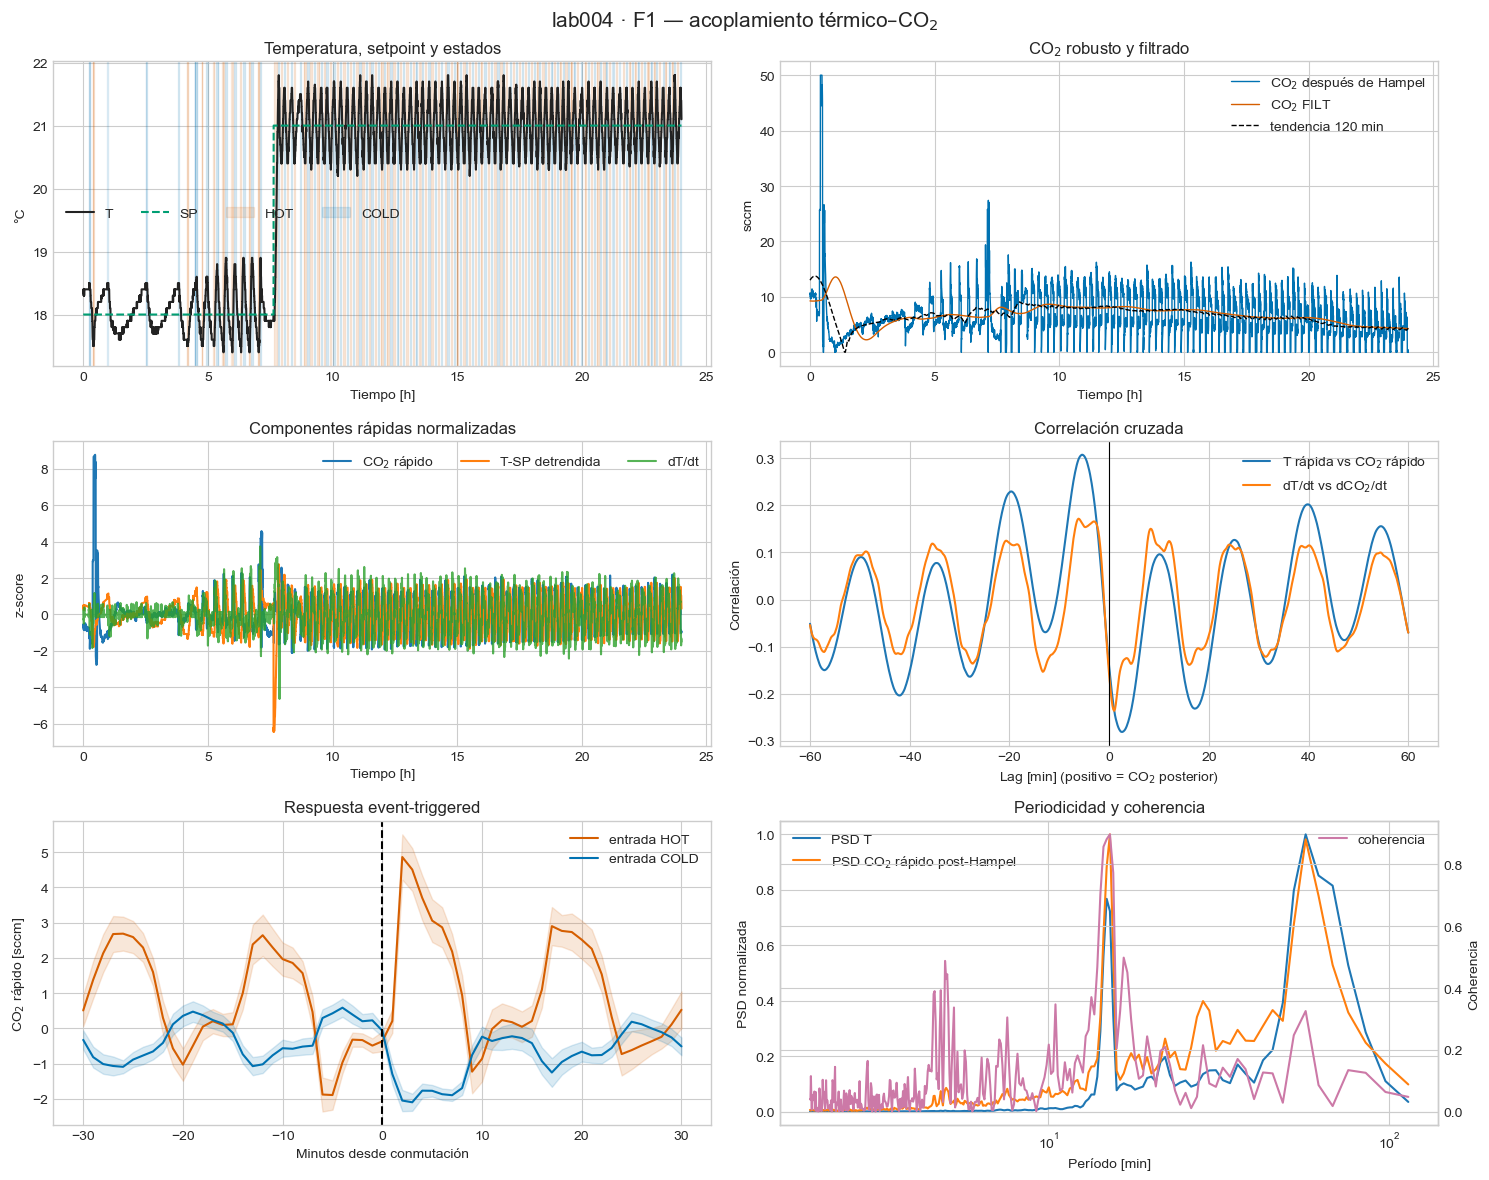

C:\Users\claud\AppData\Local\Temp\ipykernel_26488\3578276452.py:68: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  aggregate = subset.groupby("relative_min").apply(lambda g: pd.Series({


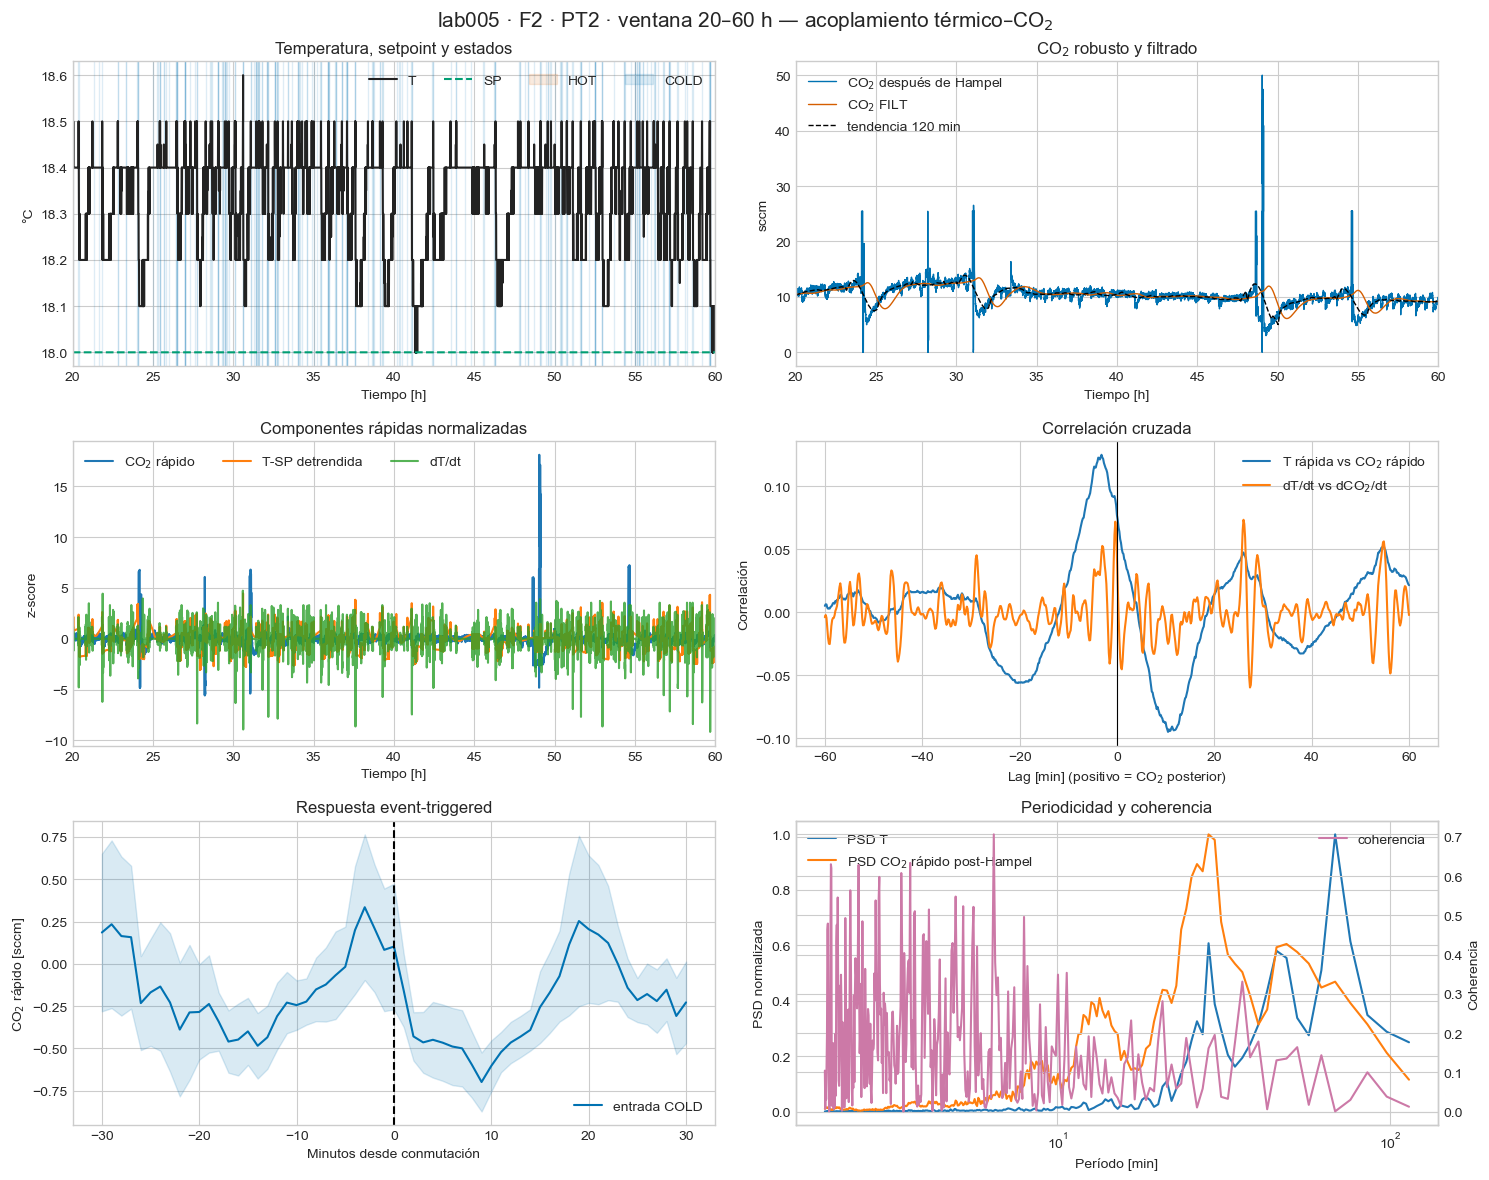

C:\Users\claud\AppData\Local\Temp\ipykernel_26488\3578276452.py:68: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  aggregate = subset.groupby("relative_min").apply(lambda g: pd.Series({
C:\Users\claud\AppData\Local\Temp\ipykernel_26488\3578276452.py:68: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  aggregate = subset.groupby("relative_min").apply(lambda g: pd.Series({


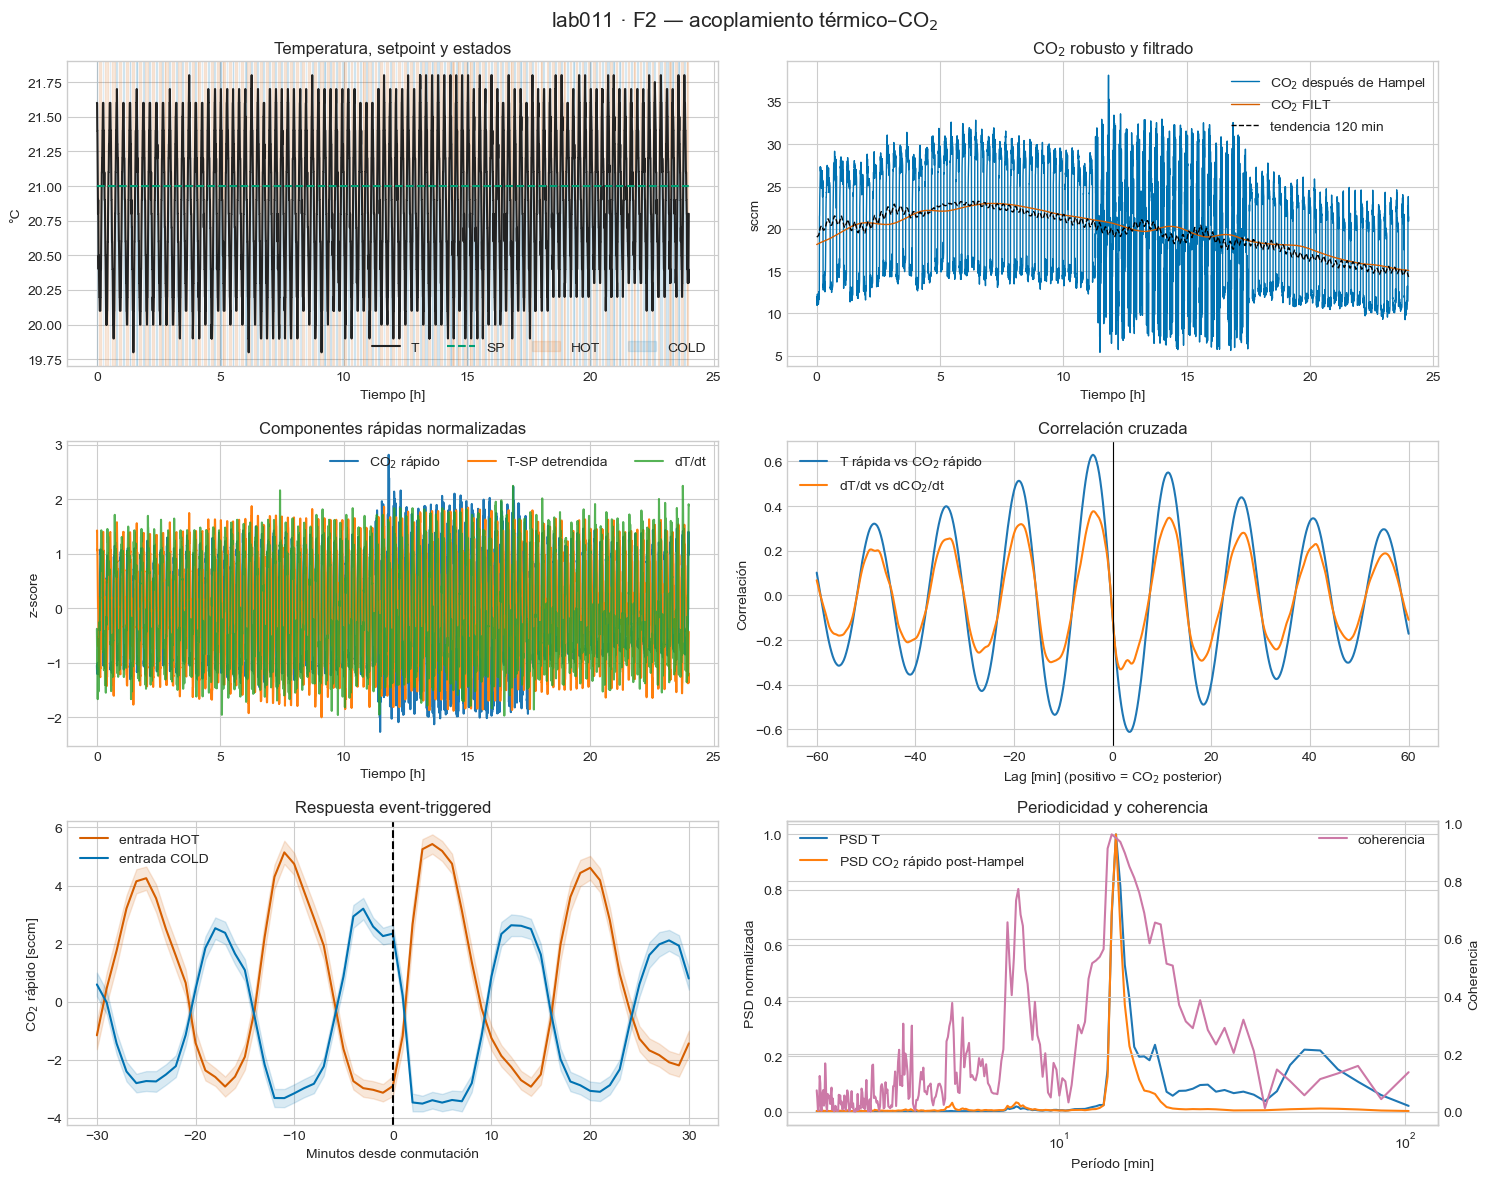

C:\Users\claud\AppData\Local\Temp\ipykernel_26488\3578276452.py:68: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  aggregate = subset.groupby("relative_min").apply(lambda g: pd.Series({
C:\Users\claud\AppData\Local\Temp\ipykernel_26488\3578276452.py:68: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  aggregate = subset.groupby("relative_min").apply(lambda g: pd.Series({


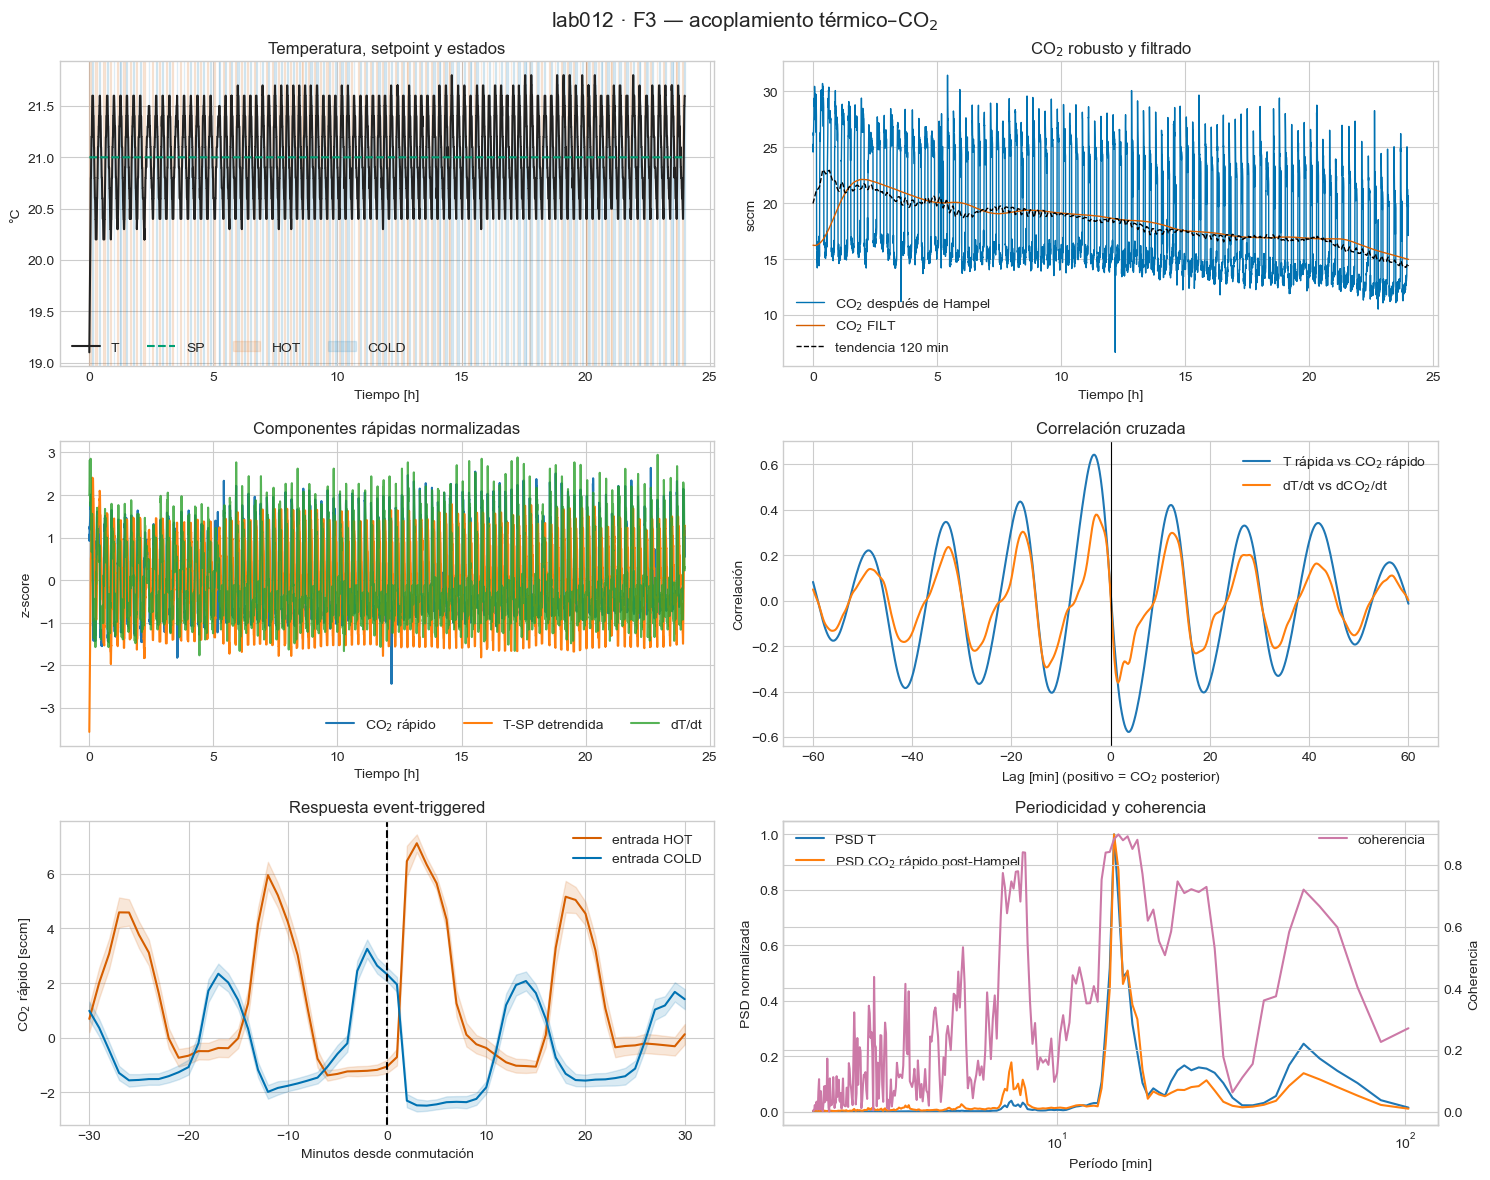

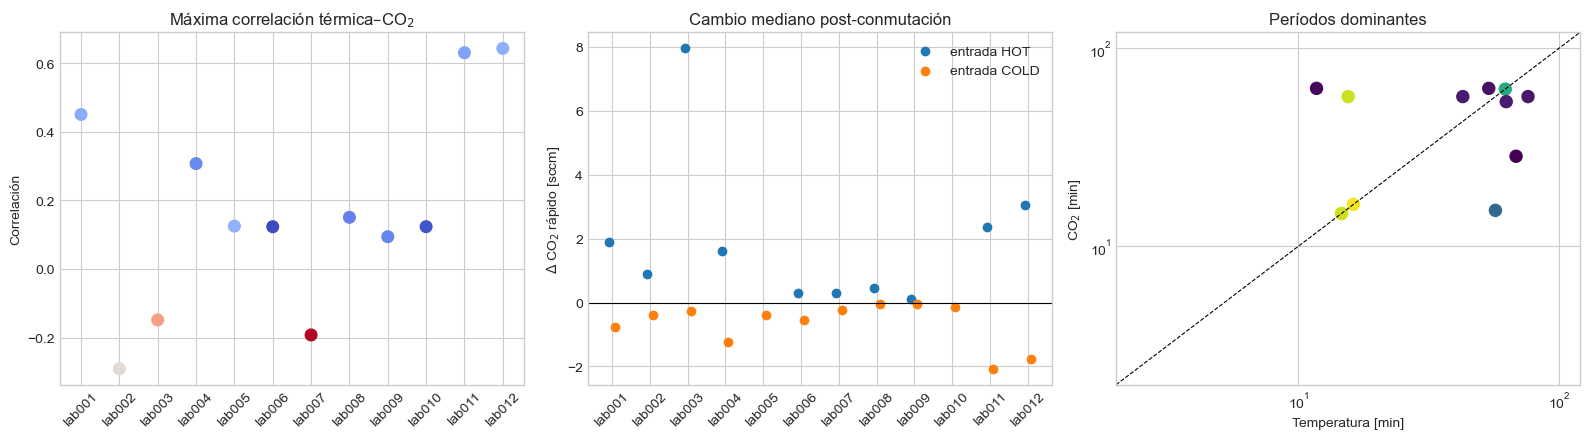

In [19]:
representatives = (
    temperature_co2_summary.assign(score=lambda d: d["best_crosscorr"].abs() * np.sqrt(d["n_thermal_events"].clip(lower=1)))
    .sort_values("score").groupby("fermenter").tail(1).sort_values("fermenter")
)
requested_labs = ["lab005"]  # LAB005_PT2: inclusión solicitada además de los casos automáticos
representatives = (
    pd.concat([representatives, temperature_co2_summary[temperature_co2_summary["lab_id"].isin(requested_labs)]])
    .drop_duplicates("lab_id").sort_values(["fermenter", "lab_id"])
)
print("Representativos:", representatives[["lab_id", "fermenter"]].to_dict("records"))

for _, row in representatives.iterrows():
    lab_id, cache = row["lab_id"], thermal_analysis_cache[row["lab_id"]]
    block, dt_s = cache["prepared"]["block"], cache["prepared"]["dt_s"]
    window_n = min(len(block), int(round(24 * 3600 / dt_s)))
    if lab_id == "lab005":
        elapsed_h = (block["timestamp"] - cache["prepared"]["experiment_start"]).dt.total_seconds() / 3600
        window_mask = elapsed_h.between(20, 60, inclusive="both")
        shown = block.loc[window_mask].reset_index(drop=True)
        time_h = elapsed_h.loc[window_mask].reset_index(drop=True)
    elif len(block) > window_n:
        activity = block["co2_fast"].rolling(window_n, center=True, min_periods=window_n // 2).std()
        center = int(activity.fillna(-np.inf).to_numpy().argmax())
        start_i = max(0, min(len(block) - window_n, center - window_n // 2))
        shown = block.iloc[start_i:start_i + window_n].copy()
        time_h = (shown["timestamp"] - shown["timestamp"].iloc[0]).dt.total_seconds() / 3600
    else:
        shown = block.copy()
        time_h = (shown["timestamp"] - shown["timestamp"].iloc[0]).dt.total_seconds() / 3600
    if lab_id == "lab005":
        assert len(shown) == 14400 and time_h.min() >= 19.99 and time_h.max() <= 60.01, (len(shown), time_h.min(), time_h.max())

    fig, axes = plt.subplots(3, 2, figsize=(15, 12))
    ax = axes[0, 0]
    ax.plot(time_h, shown["T"], label="T", color="#222222")
    ax.plot(time_h, shown["SP"], label="SP", color="#009E73", ls="--")
    ax.fill_between(time_h, 0, 1, where=shown["hot"].astype(bool), transform=ax.get_xaxis_transform(), color="#D55E00", alpha=.13, label="HOT")
    ax.fill_between(time_h, 0, 1, where=shown["cold"].astype(bool), transform=ax.get_xaxis_transform(), color="#0072B2", alpha=.13, label="COLD")
    ax.set(title="Temperatura, setpoint y estados", xlabel="Tiempo [h]", ylabel="°C"); ax.legend(ncol=4)

    ax = axes[0, 1]
    ax.plot(time_h, shown["co2_hampel"], label=r"CO$_2$ después de Hampel", color="#0072B2", lw=1)
    ax.plot(time_h, shown["co2_filt"], label=r"CO$_2$ FILT", color="#D55E00", lw=1)
    ax.plot(time_h, shown["co2_trend"], label="tendencia 120 min", color="black", ls="--", lw=1)
    ax.set(title=r"CO$_2$ robusto y filtrado", xlabel="Tiempo [h]", ylabel="sccm"); ax.legend()

    ax = axes[1, 0]
    z = lambda s: (s - s.mean()) / (s.std() + 1e-12)
    ax.plot(time_h, z(shown["co2_fast"]), label=r"CO$_2$ rápido")
    ax.plot(time_h, z(shown["temp_fast"]), label="T-SP detrendida")
    ax.plot(time_h, z(shown["dtemp_dt_c_min"]), label="dT/dt", alpha=.8)
    ax.set(title="Componentes rápidas normalizadas", xlabel="Tiempo [h]", ylabel="z-score"); ax.legend(ncol=3)
    if lab_id == "lab005":
        for time_axis in (axes[0, 0], axes[0, 1], axes[1, 0]):
            time_axis.set_xlim(20, 60)

    ax = axes[1, 1]
    for item, label in [(cache["temp_cross"], r"T rápida vs CO$_2$ rápido"), (cache["derivative_cross"], r"dT/dt vs dCO$_2$/dt")]:
        ax.plot(item["lags"] * dt_s / 60, item["curve"], label=label)
    ax.axvline(0, color="black", lw=.8)
    ax.set(title="Correlación cruzada", xlabel=r"Lag [min] (positivo = CO$_2$ posterior)", ylabel="Correlación"); ax.legend()

    ax = axes[2, 0]
    profiles = thermal_event_profiles[thermal_event_profiles["lab_id"].eq(lab_id)]
    for destination, color in [("HOT", "#D55E00"), ("COLD", "#0072B2")]:
        subset = profiles[profiles["transition"].str.endswith("->" + destination)]
        if len(subset):
            aggregate = subset.groupby("relative_min").apply(lambda g: pd.Series({
                "mean": np.average(g["co2_fast_response_mean"], weights=g["n"]),
                "sem": np.sqrt(np.average(g["co2_fast_sem"].fillna(0) ** 2, weights=g["n"])),
            })).reset_index()
            ax.plot(aggregate["relative_min"], aggregate["mean"], color=color, label=f"entrada {destination}")
            ax.fill_between(aggregate["relative_min"], aggregate["mean"] - 1.96 * aggregate["sem"], aggregate["mean"] + 1.96 * aggregate["sem"], color=color, alpha=.15)
    ax.axvline(0, color="black", ls="--")
    ax.set(title="Respuesta event-triggered", xlabel="Minutos desde conmutación", ylabel=r"CO$_2$ rápido [sccm]"); ax.legend()

    ax = axes[2, 1]
    spectral = cache["spectral"]; valid = (spectral["periods_min"] >= 2) & (spectral["periods_min"] <= 120)
    period = spectral["periods_min"][valid]
    ax.semilogx(period, spectral["temp_psd"][valid] / spectral["temp_psd"][valid].max(), label="PSD T")
    ax.semilogx(period, spectral["co2_psd"][valid] / spectral["co2_psd"][valid].max(), label=r"PSD CO$_2$ rápido post-Hampel")
    ax2 = ax.twinx(); ax2.semilogx(period, spectral["coherence"][valid], color="#CC79A7", label="coherencia")
    ax.set(title="Periodicidad y coherencia", xlabel="Período [min]", ylabel="PSD normalizada"); ax2.set_ylabel("Coherencia")
    ax.legend(loc="upper left"); ax2.legend(loc="upper right")
    segment_label = "pt2" if lab_id == "lab005" else ""
    title_segment = " · PT2 · ventana 20–60 h" if segment_label else ""
    fig.suptitle(rf"{lab_id} · {row['fermenter']}{title_segment} — acoplamiento térmico–CO$_2$", fontsize=15)
    file_segment = f"_{segment_label}" if segment_label else ""
    fig.tight_layout()
    fig.savefig(FIGURES / f"thermal_coupling_{lab_id}_{row['fermenter']}{file_segment}.png", dpi=150)
    if lab_id == "lab005":
        fig.savefig(FIGURES / "thermal_coupling_lab005_F2_pt2_h20_h60.png", dpi=150)
    plt.show(); plt.close(fig)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
x = np.arange(len(temperature_co2_summary))
axes[0].scatter(x, temperature_co2_summary["best_crosscorr"], c=temperature_co2_summary["best_lag_min"], cmap="coolwarm", s=70)
axes[0].set_xticks(x, temperature_co2_summary["lab_id"], rotation=45); axes[0].set(title=r"Máxima correlación térmica–CO$_2$", ylabel="Correlación")
axes[1].scatter(x-.08, temperature_co2_summary["hot_event_effect"], label="entrada HOT")
axes[1].scatter(x+.08, temperature_co2_summary["cold_event_effect"], label="entrada COLD")
axes[1].axhline(0, color="black", lw=.8); axes[1].set_xticks(x, temperature_co2_summary["lab_id"], rotation=45)
axes[1].set(title="Cambio mediano post-conmutación", ylabel=r"$\Delta$ CO$_2$ rápido [sccm]"); axes[1].legend()
axes[2].scatter(temperature_co2_summary["dominant_temp_period_min"], temperature_co2_summary["dominant_co2_period_min"], c=temperature_co2_summary["coherence_at_temp_peak"], cmap="viridis", s=75)
axes[2].plot([2,120],[2,120],"k--",lw=.8); axes[2].set(xscale="log",yscale="log",xlim=(2,120),ylim=(2,120),title="Períodos dominantes",xlabel="Temperatura [min]",ylabel=r"CO$_2$ [min]")
fig.tight_layout(); fig.savefig(FIGURES / "thermal_coupling_summary.png", dpi=160); plt.show(); plt.close(fig)


In [20]:
by_thermal_fermenter = temperature_co2_summary.groupby("fermenter").agg(
    experiments=("lab_id", "count"), crosscorr_median=("best_crosscorr", "median"),
    lag_median_min=("best_lag_min", "median"), hot_effect_median=("hot_event_effect", "median"),
    cold_effect_median=("cold_event_effect", "median"), coherence_median=("coherence_at_temp_peak", "median"),
    attenuation_median_pct=("fast_variance_attenuation_pct", "median"),
)
by_thermal_fermenter.to_csv(RESULTS / "temperature_co2_by_fermenter.csv")
display(by_thermal_fermenter.round(4))

strong_cross = temperature_co2_summary["best_crosscorr"].abs().ge(.3)
shared_period = (
    np.abs(np.log(temperature_co2_summary["dominant_temp_period_min"] / temperature_co2_summary["dominant_co2_period_min"])) <= np.log(1.25)
) & temperature_co2_summary["coherence_at_temp_peak"].ge(.4)
hot_supported = temperature_co2_summary["hot_effect_ci_low"].gt(0) | temperature_co2_summary["hot_effect_ci_high"].lt(0)
cold_supported = temperature_co2_summary["cold_effect_ci_low"].gt(0) | temperature_co2_summary["cold_effect_ci_high"].lt(0)
print("RESUMEN TÉRMICO REPRODUCIBLE")
print(f"- Experimentos sincronizados: {len(temperature_co2_summary)}")
print(f"- |correlación cruzada| >= 0.30: {strong_cross.sum()}/{len(strong_cross)}")
print(f"- Periodicidad compartida (±25%, coherencia >= 0.4): {shared_period.sum()}/{len(shared_period)}")
print(f"- Efecto HOT con IC bootstrap fuera de cero: {hot_supported.sum()}/{len(hot_supported)}")
print(f"- Efecto COLD con IC bootstrap fuera de cero: {cold_supported.sum()}/{len(cold_supported)}")
print(f"- Mediana de atenuación de varianza rápida por FILT: {temperature_co2_summary['fast_variance_attenuation_pct'].median():.1f}%")
print("- Son asociaciones observacionales; no demuestran causalidad.")


,experiments,crosscorr_median,lag_median_min,hot_effect_median,cold_effect_median,coherence_median,attenuation_median_pct
fermenter,,,,,,,
F1,4,0.2151,-4.4167,1.6048,-0.5072,0.2004,99.6495
F2,4,0.1377,-3.5833,0.8990,-0.3901,0.4609,99.6607
F3,4,0.1085,-4.3750,1.6729,-0.4064,0.3198,99.7538


RESUMEN TÉRMICO REPRODUCIBLE
- Experimentos sincronizados: 12
- |correlación cruzada| >= 0.30: 4/12
- Periodicidad compartida (±25%, coherencia >= 0.4): 4/12
- Efecto HOT con IC bootstrap fuera de cero: 8/12
- Efecto COLD con IC bootstrap fuera de cero: 11/12
- Mediana de atenuación de varianza rápida por FILT: 99.7%
- Son asociaciones observacionales; no demuestran causalidad.


### Criterios de interpretación y limitaciones

- Los estados HOT/COLD son registros directos, no inferencias desde T/SP.
- El Hampel se reconstruye desde cada RAW; el estado anterior al segmento no existe. Los primeros 120 s son transitorio de reconstrucción.
- La grilla común sigue el período de CO₂. Temperatura se agrega por mediana, estados por último valor y sólo se rellenan hasta dos huecos internos.
- La correlación máxima se restringe a ±60 min. Un máximo puede reflejar una tercera dinámica común y no prueba causalidad.
- Los intervalos bootstrap describen variación entre conmutaciones, pero eventos cercanos no son independientes.
- El análisis espectral se restringe a períodos de 2–120 min y se interpreta junto con coherencia, eventos y repetibilidad.
- Una asociación reproducible indicaría que parte de lo atenuado por Butterworth contiene dinámica física relacionada con el control; no implica que toda variación rápida deba conservarse ni justifica todavía cambiar τ.
